In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("3. Dataset - DA'26.csv")

### Exploratory data analysis

In [3]:
df.head()

,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2,pl_orbeccen,pl_orbincl,pl_insol,pl_eqt,...,releasedate,disc_pubdate,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec,pl_rade,pl_bmasse
0,4.765591,0.000028,-0.000029,0.0522,NaN,NaN,0.00,88.81,439.4200,1168.00,...,25-08-2015,2022-02,0.0,0.0,0.0,0.0,0.0,0.0,0.93000,0.76
1,3.700633,0.000018,-0.000018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,25-09-2018,2022-02,0.0,0.0,0.0,0.0,0.0,0.0,2.30200,4.10
2,4.225350,0.000022,-0.000022,NaN,NaN,NaN,NaN,NaN,342.3014,1097.04,...,28-03-2023,2016-05,0.0,0.0,0.0,0.0,0.0,0.0,8.88932,59.00
3,4.510045,0.000019,-0.000019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,18-04-2019,2016-05,0.0,0.0,0.0,0.0,0.0,0.0,2.30200,2.73
4,85.313900,0.001700,-0.001700,NaN,NaN,NaN,0.01,NaN,NaN,NaN,...,10-11-2021,2013-01,0.0,0.0,0.0,0.0,0.0,0.0,8.98000,4.00


In [4]:
df.columns

Index(['pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbsmax',
       'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbeccen', 'pl_orbincl',
       'pl_insol', 'pl_eqt', 'pl_imppar', 'pl_trandur', 'pl_ratror',
       'pl_ratrorerr1', 'pl_ratrorerr2', 'st_mass', 'st_masserr1',
       'st_masserr2', 'st_rad', 'st_raderr1', 'st_raderr2', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_logg', 'st_loggerr1', 'st_loggerr2',
       'st_met', 'st_meterr1', 'st_meterr2', 'st_dens', 'sy_vmag',
       'sy_vmagerr1', 'sy_vmagerr2', 'sy_bmag', 'sy_bmagerr1', 'sy_bmagerr2',
       'sy_jmag', 'sy_jmagerr1', 'sy_jmagerr2', 'sy_hmag', 'sy_hmagerr1',
       'sy_hmagerr2', 'sy_kmag', 'sy_kmagerr1', 'sy_kmagerr2', 'sy_w1mag',
       'sy_w1magerr1', 'sy_w1magerr2', 'sy_w2mag', 'sy_w2magerr1',
       'sy_w2magerr2', 'sy_w3mag', 'sy_w3magerr1', 'sy_w3magerr2', 'sy_w4mag',
       'sy_gaiamag', 'sy_tmag', 'sy_snum', 'sy_pnum', 'sy_mnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype', 'sy

In [5]:
unwanted_features = [

    'pl_name',
    'hostname',
    'pl_letter',
    'rowid',
    'rowupdate',
    'pl_pubdate',
    'releasedate',
    'disc_pubdate',

    'pl_orbpererr1',
    'pl_orbpererr2',
    'pl_orbsmaxerr1',
    'pl_orbsmaxerr2',
    'pl_ratrorerr1',
    'pl_ratrorerr2',

    'st_masserr1',
    'st_masserr2',
    'st_raderr1',
    'st_raderr2',
    'st_tefferr1',
    'st_tefferr2',
    'st_loggerr1',
    'st_loggerr2',
    'st_meterr1',
    'st_meterr2',

    'sy_vmagerr1',
    'sy_vmagerr2',
    'sy_bmagerr1',
    'sy_bmagerr2',
    'sy_jmagerr1',
    'sy_jmagerr2',
    'sy_hmagerr1',
    'sy_hmagerr2',
    'sy_kmagerr1',
    'sy_kmagerr2',
    'sy_w1magerr1',
    'sy_w1magerr2',
    'sy_w2magerr1',
    'sy_w2magerr2',
    'sy_w3magerr1',
    'sy_w3magerr2',

    'discoverymethod',
    'disc_facility',
    'soltype',

    'cosmic_noise_1',
    'cosmic_noise_2',

    'pl_orbper_noisy',
    'pl_orbsmax_noisy'
]


df = df.drop(columns=unwanted_features, errors='ignore')

In [6]:
df.head()

,pl_orbper,pl_orbsmax,pl_orbeccen,pl_orbincl,pl_insol,pl_eqt,pl_imppar,pl_trandur,pl_ratror,st_mass,...,orbital_size_score,stellar_scale_score,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec,pl_rade,pl_bmasse
0,4.765591,0.0522,0.00,88.81,439.4200,1168.00,0.3305,2.16500,0.007593,0.833806,...,3.351574,1.962000,0.0,0.0,0.0,0.0,0.0,0.0,0.93000,0.76
1,3.700633,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,2.30200,4.10
2,4.225350,NaN,NaN,NaN,342.3014,1097.04,NaN,2.76953,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,8.88932,59.00
3,4.510045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.934793,...,NaN,1.783701,0.0,0.0,0.0,0.0,0.0,0.0,2.30200,2.73
4,85.313900,NaN,0.01,NaN,NaN,NaN,NaN,NaN,NaN,0.990762,...,NaN,1.866000,0.0,0.0,0.0,0.0,0.0,0.0,8.98000,4.00


In [7]:
df.isnull()

,pl_orbper,pl_orbsmax,pl_orbeccen,pl_orbincl,pl_insol,pl_eqt,pl_imppar,pl_trandur,pl_ratror,st_mass,...,orbital_size_score,stellar_scale_score,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec,pl_rade,pl_bmasse
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,True,True,True,True,True,True,True,True,...,True,True,False,False,False,False,False,False,False,False
2,False,True,True,True,False,False,True,False,True,True,...,True,True,False,False,False,False,False,False,False,False
3,False,True,True,True,True,True,True,True,True,False,...,True,False,False,False,False,False,False,False,False,False
4,False,True,False,True,True,True,True,True,True,False,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39908,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
39909,False,True,True,True,True,True,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
39910,True,False,False,False,True,True,True,True,True,True,...,True,True,False,False,False,False,False,False,False,False
39911,False,False,False,True,True,True,True,True,True,False,...,False,True,False,False,False,False,False,False,False,False


In [8]:
(df.isnull().sum()/39913)*100

pl_orbper               8.528550
pl_orbsmax             44.203643
pl_orbeccen            52.459099
pl_orbincl             55.718688
pl_insol               56.573046
pl_eqt                 56.139604
pl_imppar              56.292436
pl_trandur             43.424448
pl_ratror              45.506477
st_mass                15.979756
st_rad                  8.578659
st_teff                 8.994563
st_logg                22.491419
st_met                 37.396337
st_dens                43.452008
sy_vmag                 2.237366
sy_bmag                 3.916017
sy_jmag                 2.317541
sy_hmag                 2.244883
sy_kmag                 2.249894
sy_w1mag                7.624082
sy_w2mag                7.621577
sy_w3mag                7.626588
sy_w4mag                7.634104
sy_gaiamag              2.983990
sy_tmag                 2.219828
sy_snum                 0.000000
sy_pnum                 0.000000
sy_mnum                 0.000000
disc_year               0.005011
sy_dist   

In [9]:
# Calculate percentage of null values in each column
null_percentage = (df.isnull().sum() / len(df)) * 100

# Find columns having more than 40% null values
columns_to_remove = null_percentage[null_percentage > 40].index

# Remove those columns
df = df.drop(columns=columns_to_remove)

# Display removed columns
print("Removed columns:")
print(list(columns_to_remove))

# Check new dataset shape
print("New dataset shape:")
print(df.shape)

Removed columns:
['pl_orbsmax', 'pl_orbeccen', 'pl_orbincl', 'pl_insol', 'pl_eqt', 'pl_imppar', 'pl_trandur', 'pl_ratror', 'st_dens', 'orbital_size_score']
New dataset shape:
(39913, 39)


In [10]:
len(df)

39913

In [11]:
(df.isnull().sum()/len(df))*100

pl_orbper               8.528550
st_mass                15.979756
st_rad                  8.578659
st_teff                 8.994563
st_logg                22.491419
st_met                 37.396337
sy_vmag                 2.237366
sy_bmag                 3.916017
sy_jmag                 2.317541
sy_hmag                 2.244883
sy_kmag                 2.249894
sy_w1mag                7.624082
sy_w2mag                7.621577
sy_w3mag                7.626588
sy_w4mag                7.634104
sy_gaiamag              2.983990
sy_tmag                 2.219828
sy_snum                 0.000000
sy_pnum                 0.000000
sy_mnum                 0.000000
disc_year               0.005011
sy_dist                 2.269937
sy_disterr1             4.432140
sy_disterr2             4.432140
sy_plx                  6.268634
sy_pm                   2.540526
sy_pmra                 2.540526
sy_pmdec                2.540526
glon                    0.130283
glat                    0.130283
stellar_sc

In [12]:
df.dropna(inplace = True)

In [13]:
df['pl_rade'].describe()

count    1.967400e+04
mean     2.613479e+08
std      3.665767e+10
min      2.700000e-01
25%      1.760000e+00
50%      2.302000e+00
75%      2.910000e+00
max      5.141752e+12
Name: pl_rade, dtype: float64

In [14]:
print (df.shape)
print(df.columns)

(19674, 39)
Index(['pl_orbper', 'st_mass', 'st_rad', 'st_teff', 'st_logg', 'st_met',
       'sy_vmag', 'sy_bmag', 'sy_jmag', 'sy_hmag', 'sy_kmag', 'sy_w1mag',
       'sy_w2mag', 'sy_w3mag', 'sy_w4mag', 'sy_gaiamag', 'sy_tmag', 'sy_snum',
       'sy_pnum', 'sy_mnum', 'disc_year', 'sy_dist', 'sy_disterr1',
       'sy_disterr2', 'sy_plx', 'sy_pm', 'sy_pmra', 'sy_pmdec', 'glon', 'glat',
       'stellar_scale_score', 'st_nphot', 'st_nrvc', 'st_nspec', 'pl_nespec',
       'pl_ntranspec', 'pl_ndispec', 'pl_rade', 'pl_bmasse'],
      dtype='str')


(19674, 39)


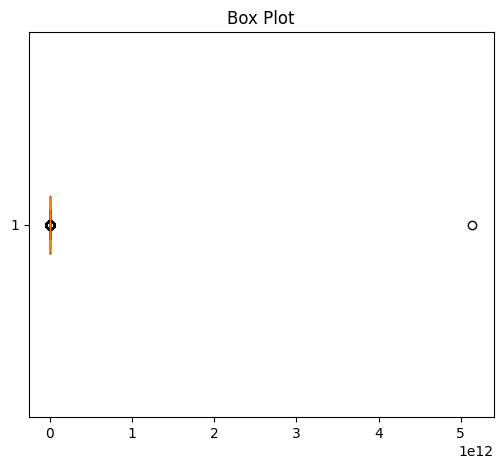

In [15]:
import matplotlib.pyplot as plt
print (df.shape)
plt.figure(figsize=(6,5))
plt.boxplot(df['pl_rade'], vert = False)
plt.title("Box Plot")
plt.show()

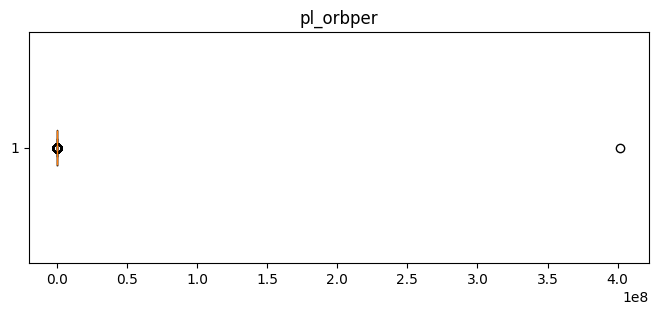

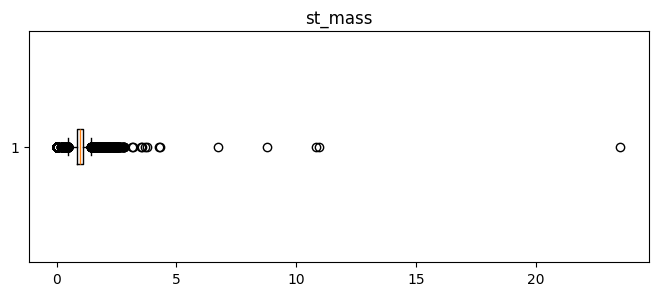

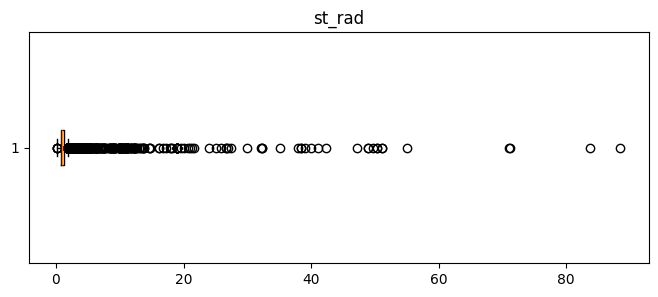

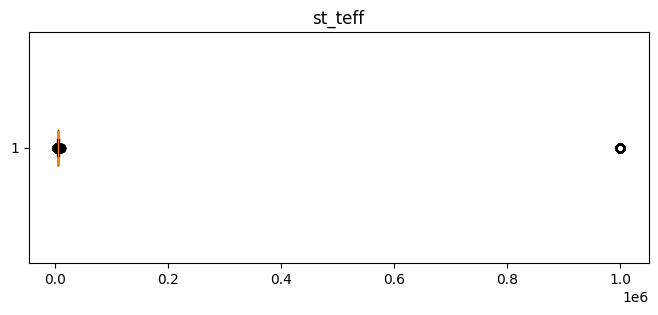

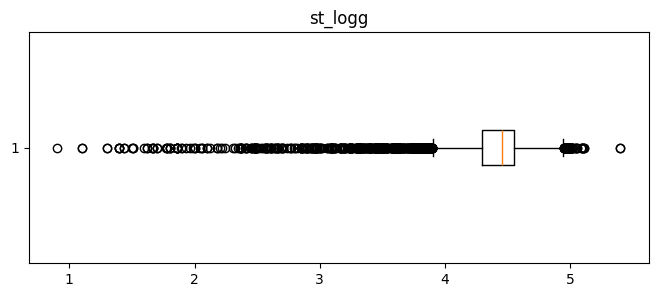

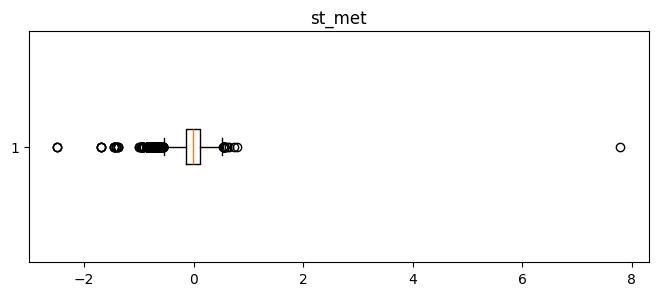

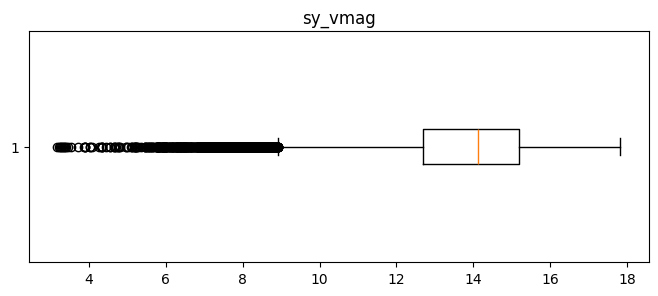

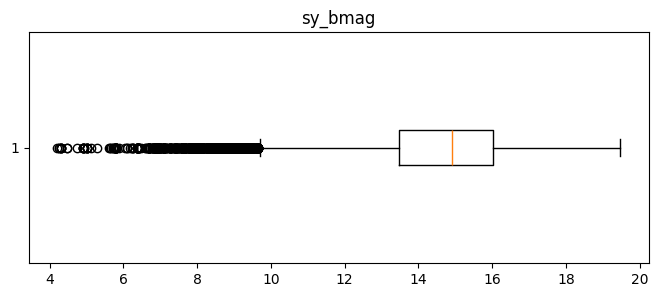

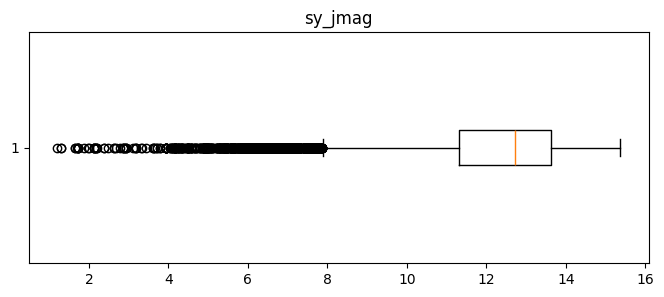

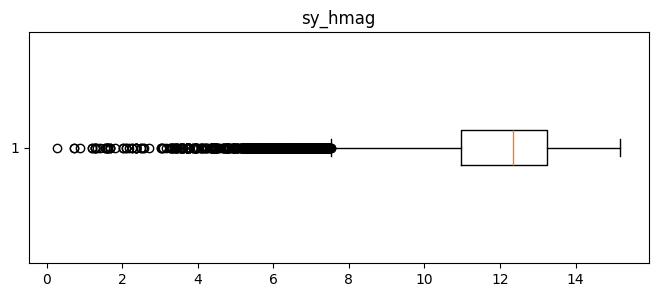

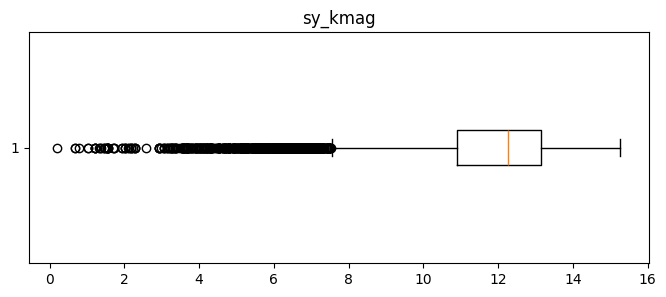

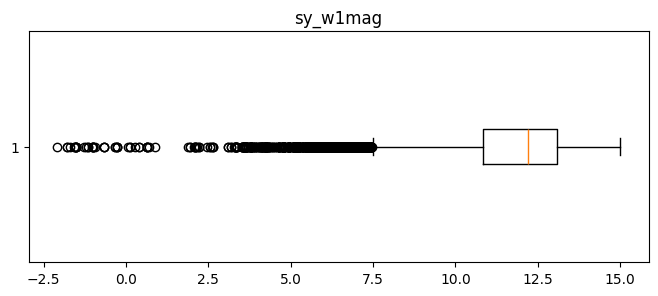

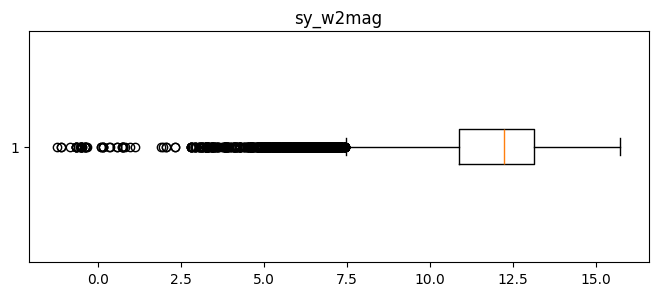

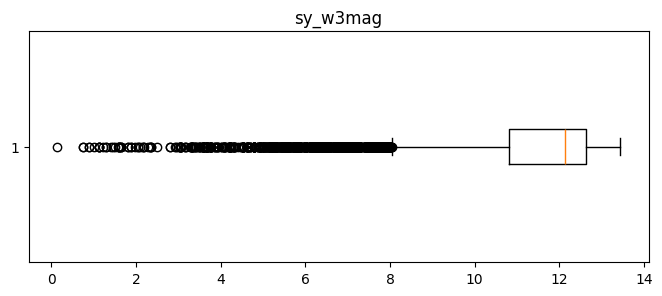

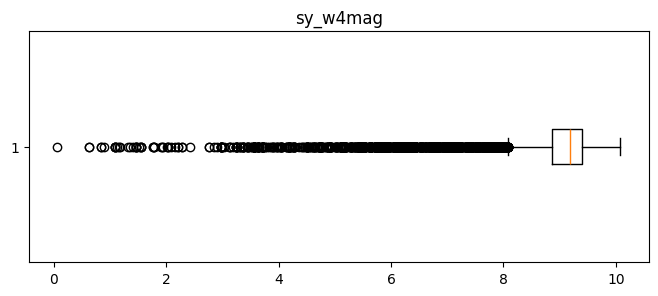

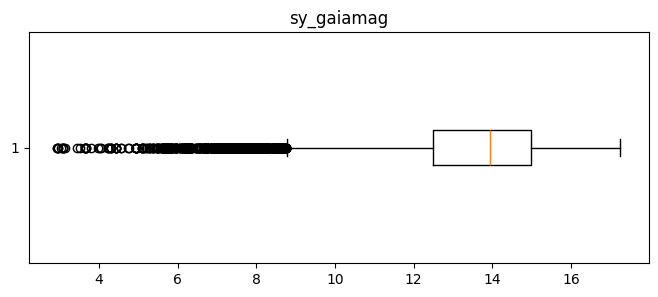

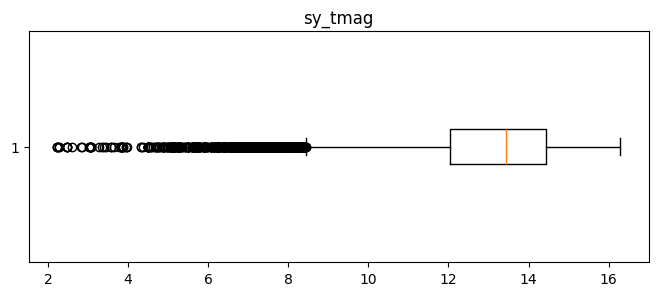

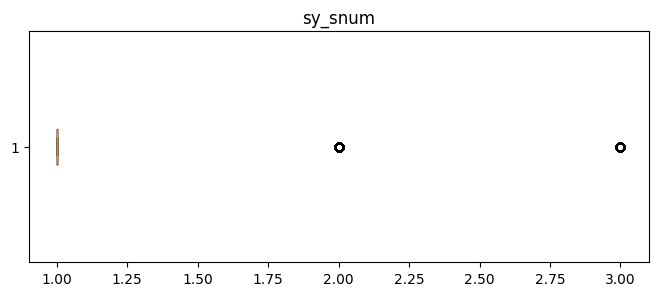

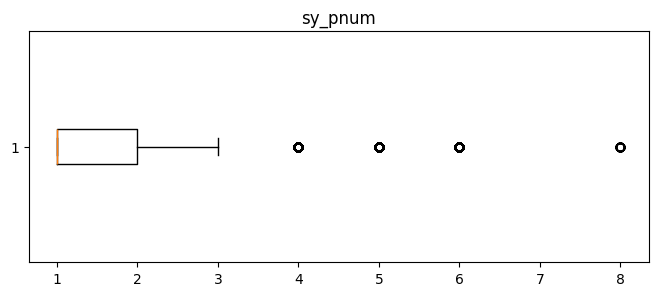

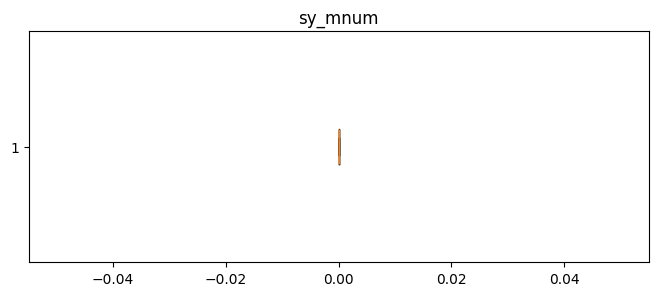

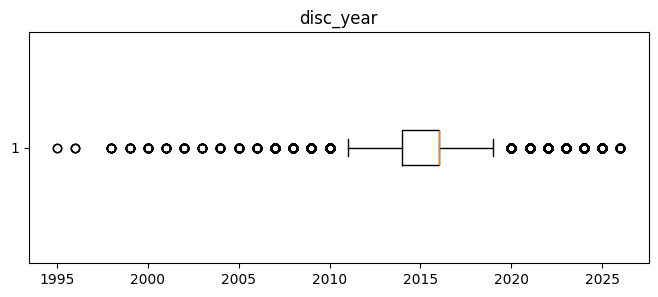

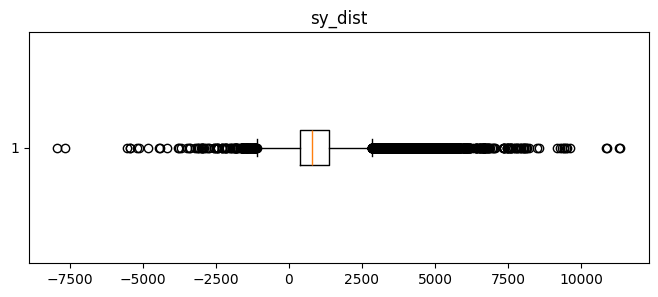

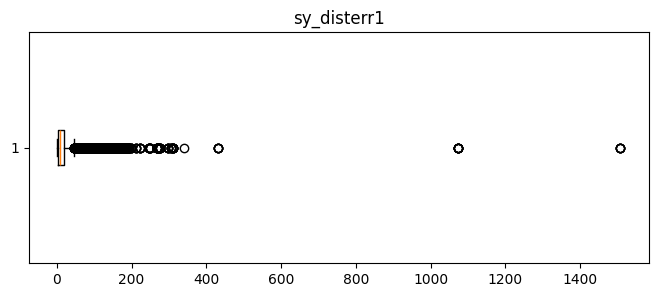

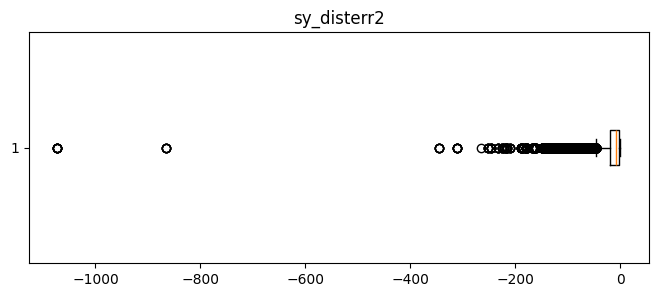

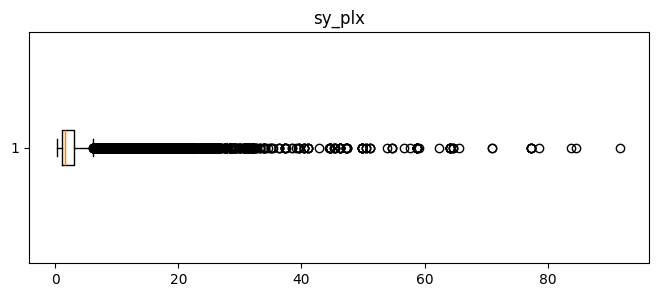

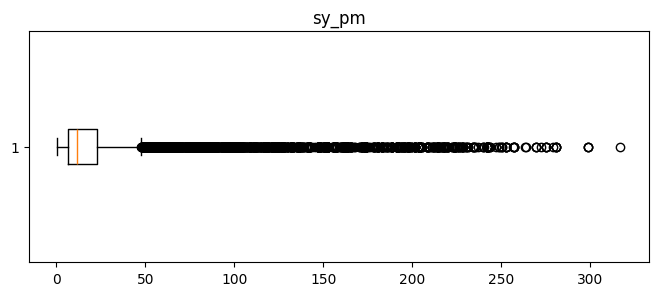

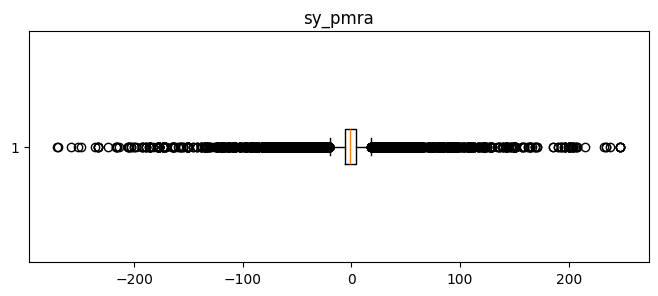

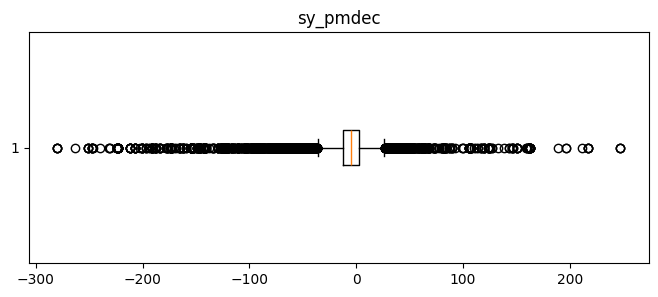

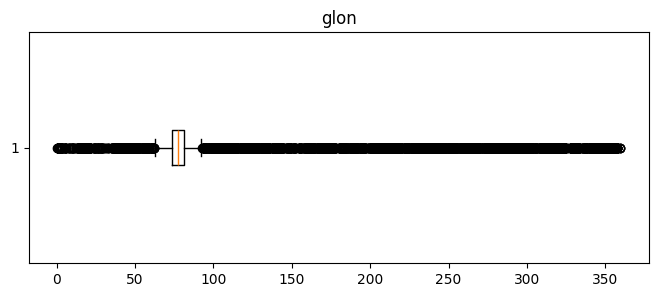

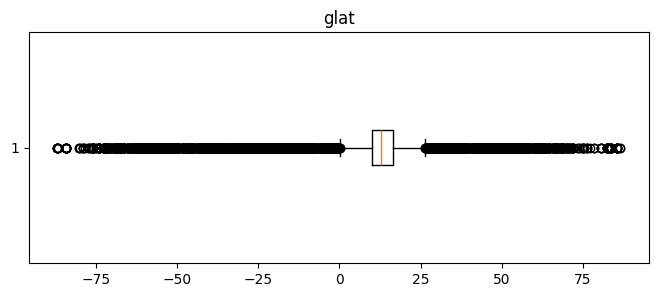

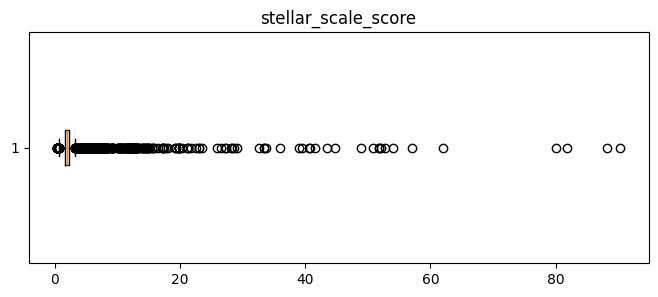

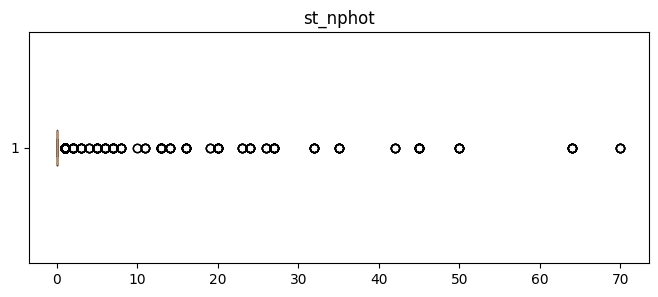

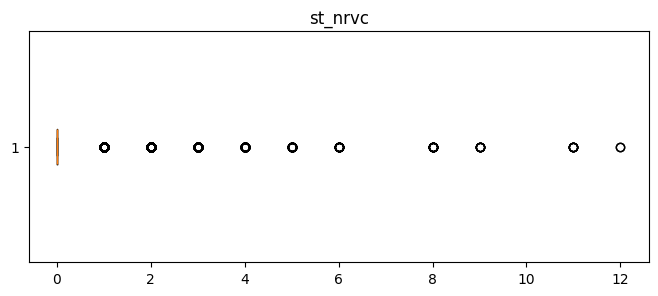

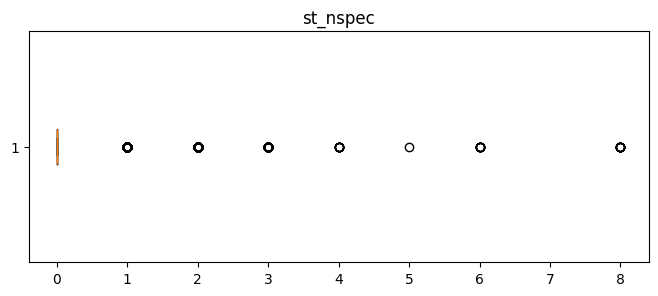

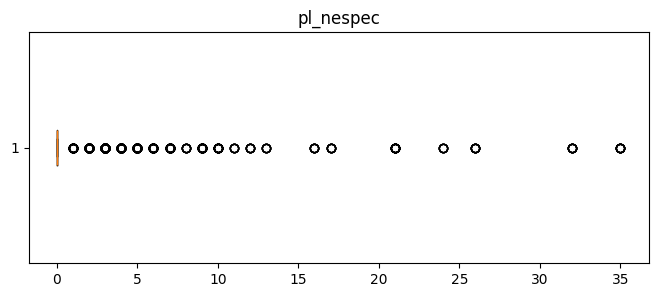

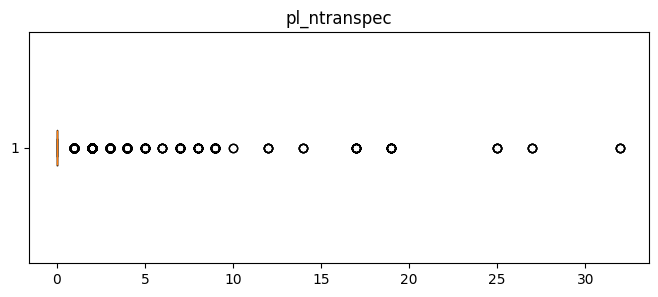

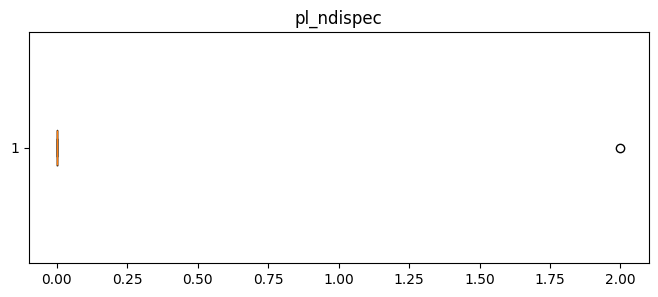

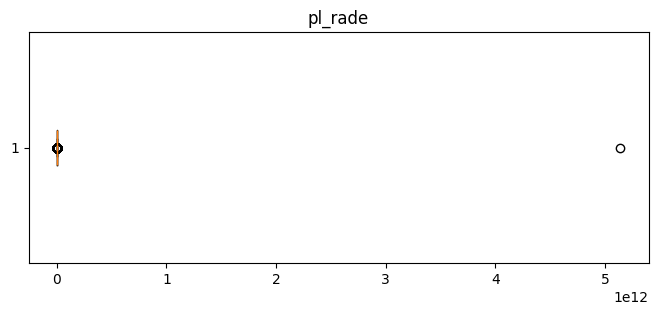

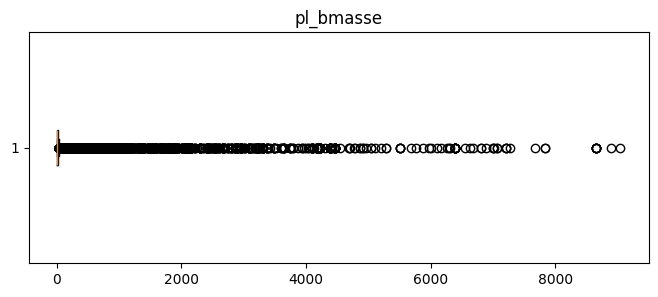

In [16]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    plt.figure(figsize=(8,3))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(col)
    plt.show()

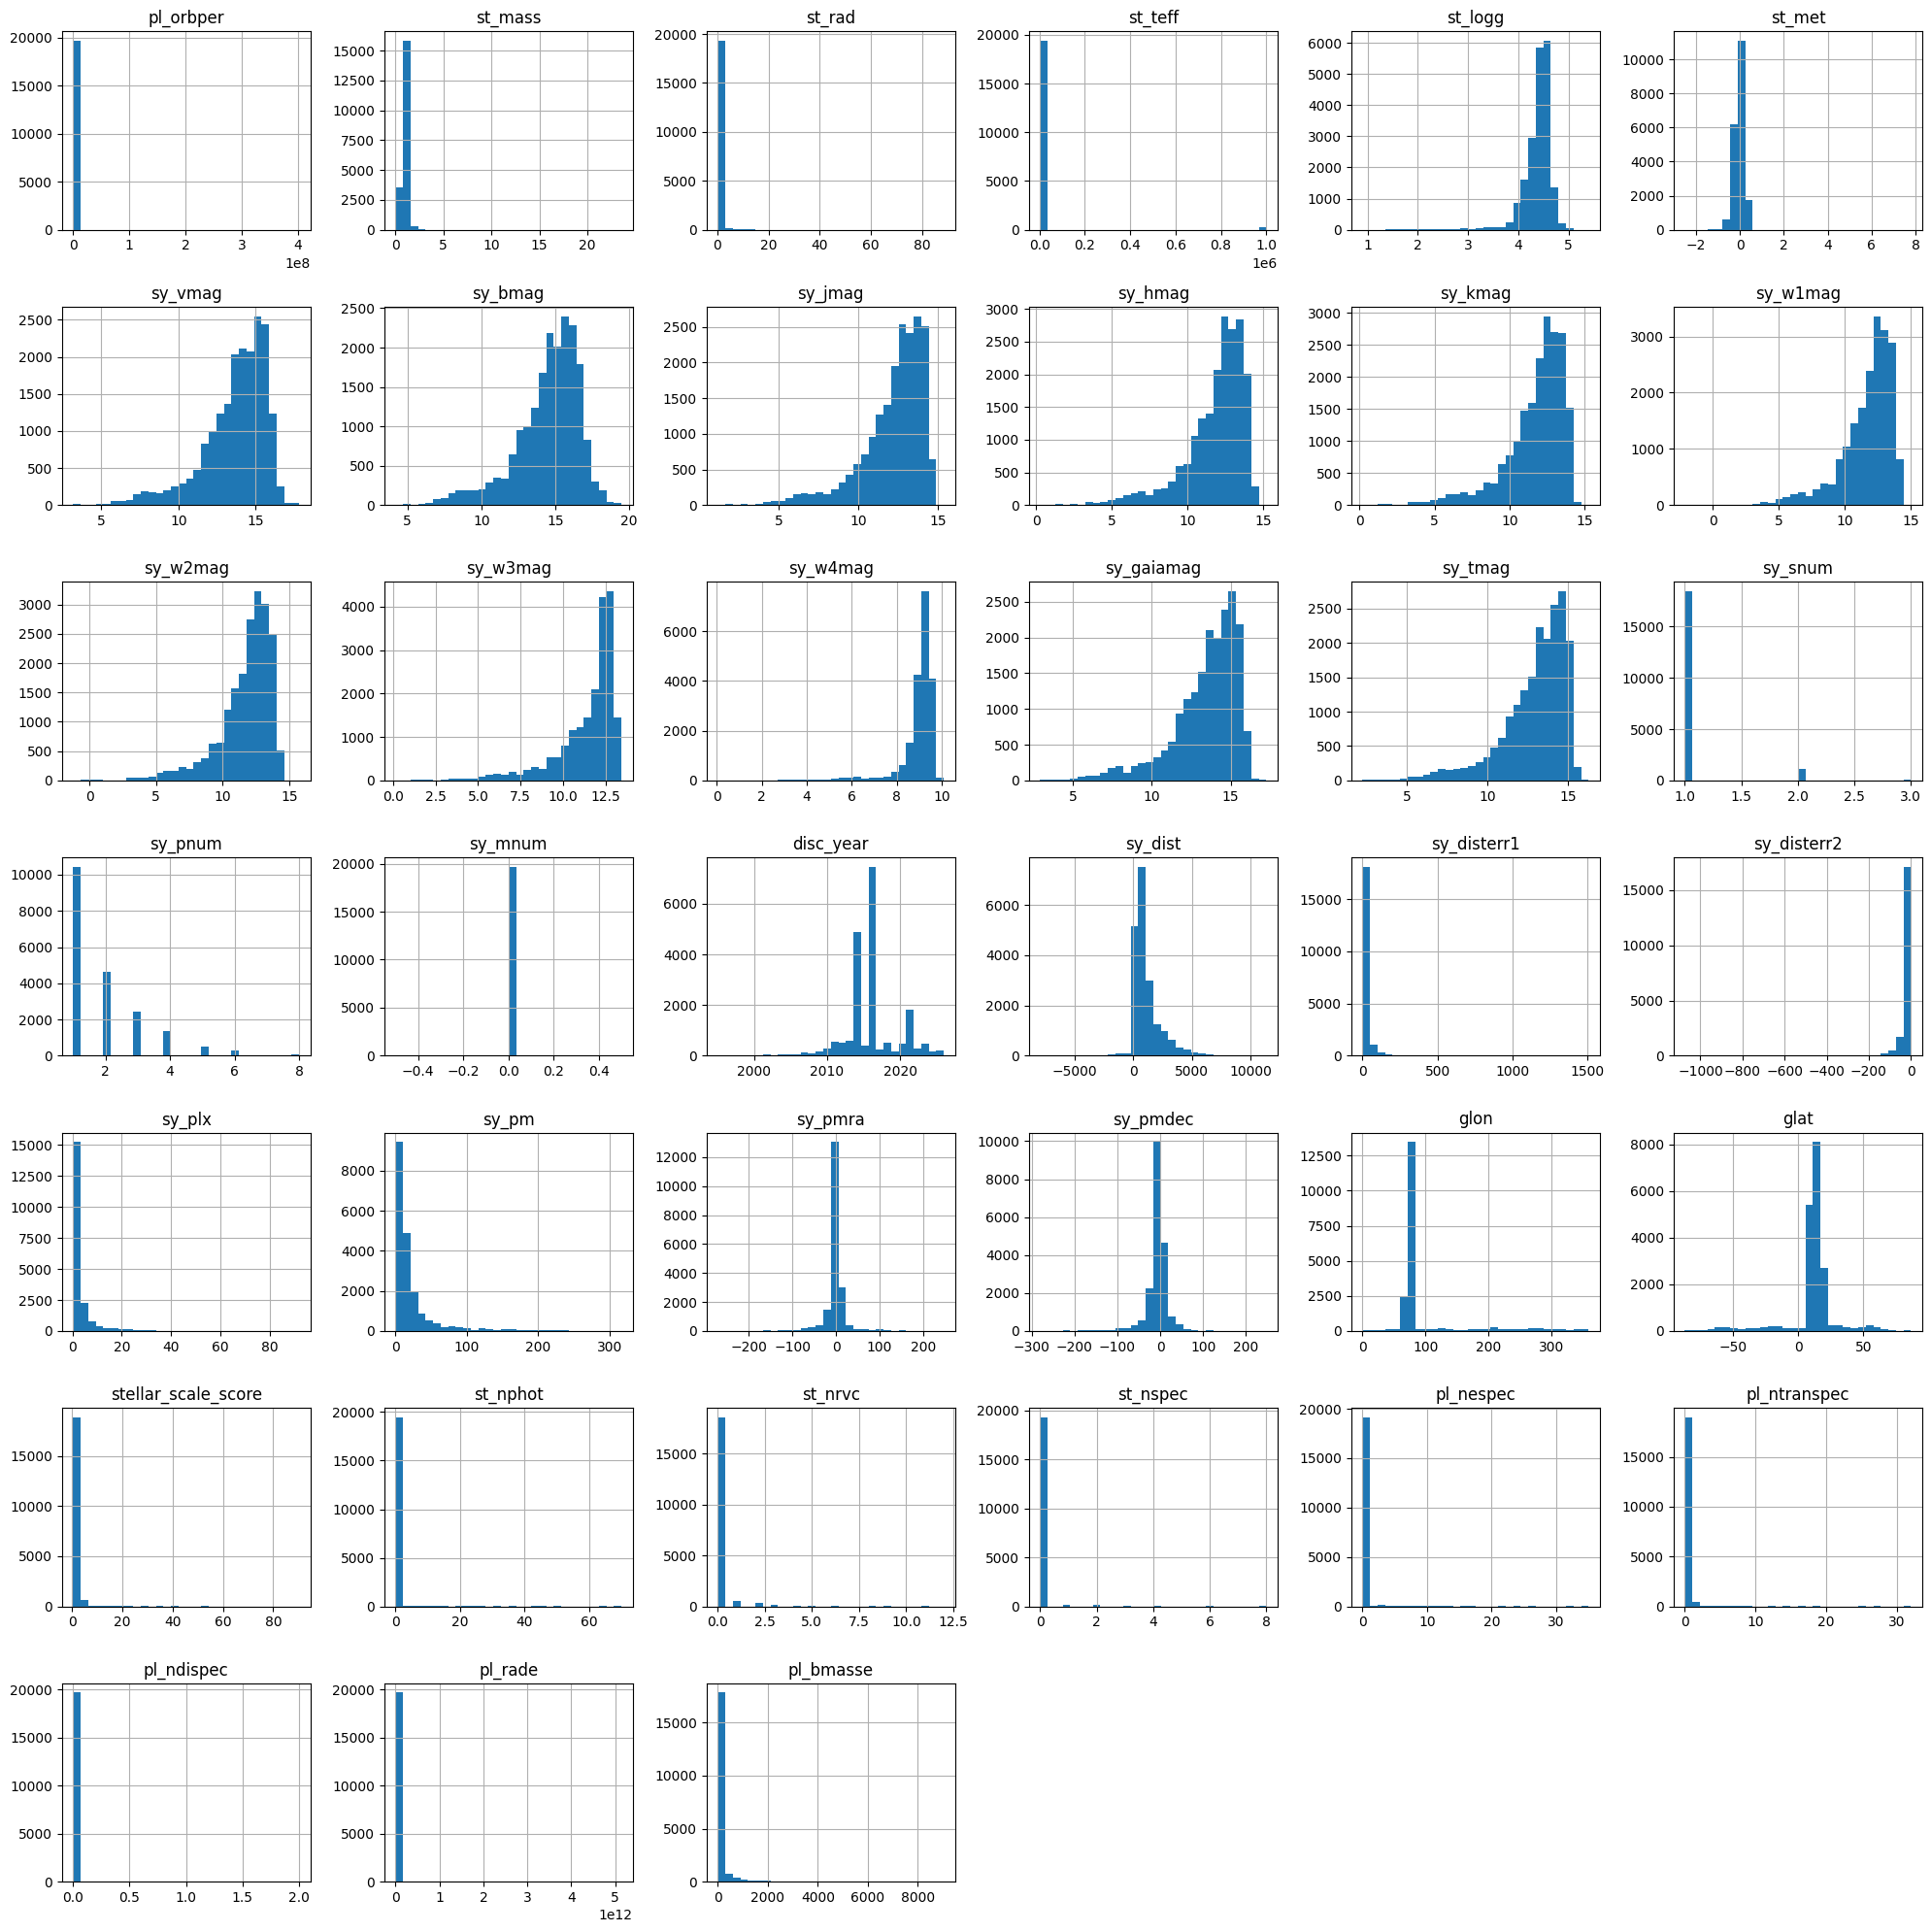

In [17]:
import matplotlib.pyplot as plt

df.hist(figsize=(20,20), bins=30)

plt.tight_layout()

plt.show()

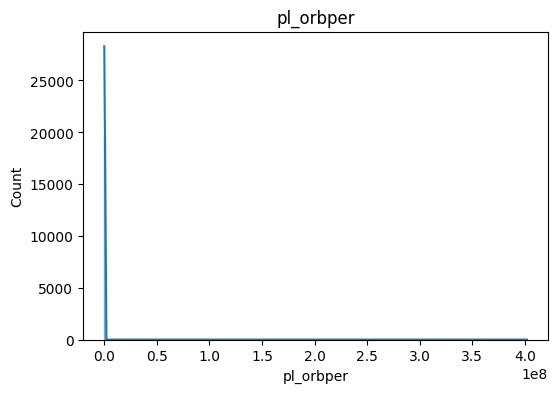

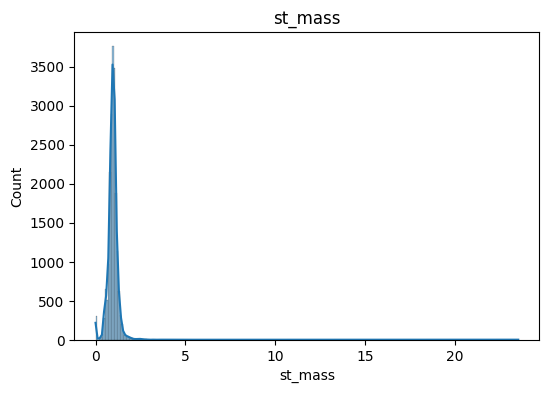

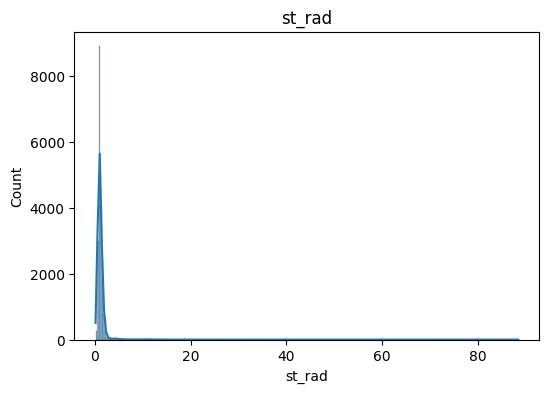

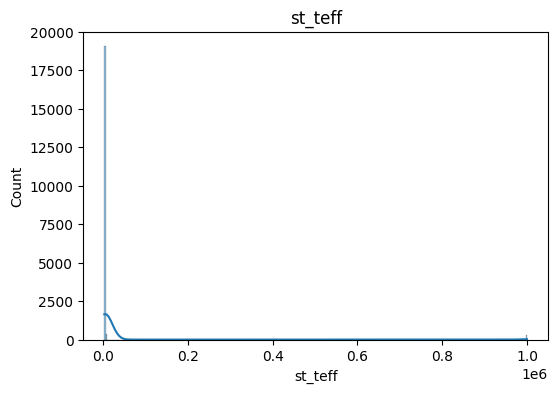

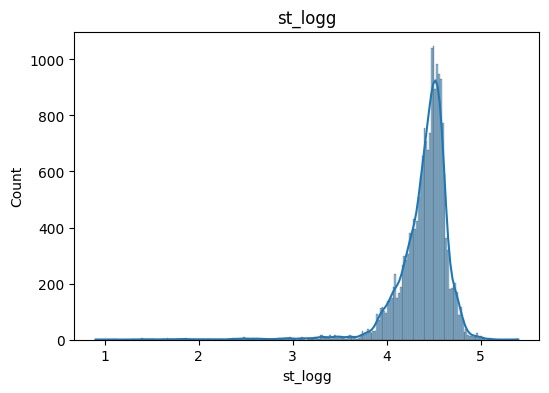

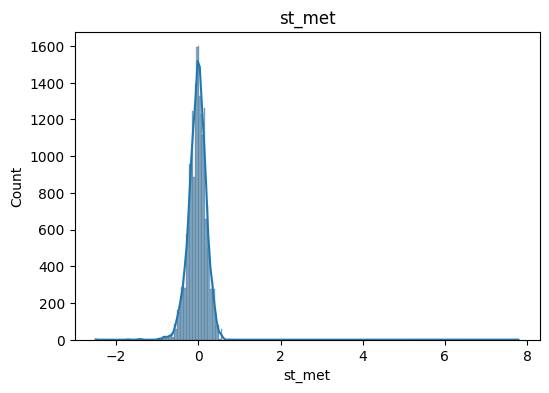

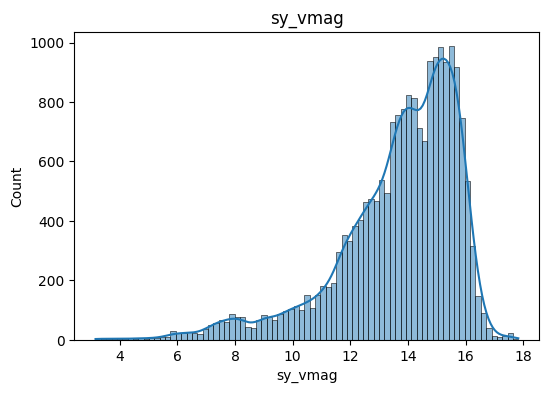

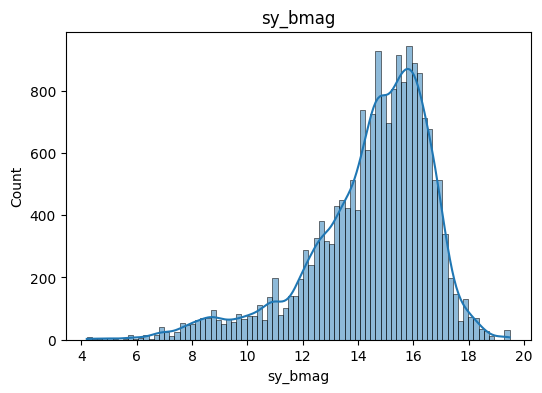

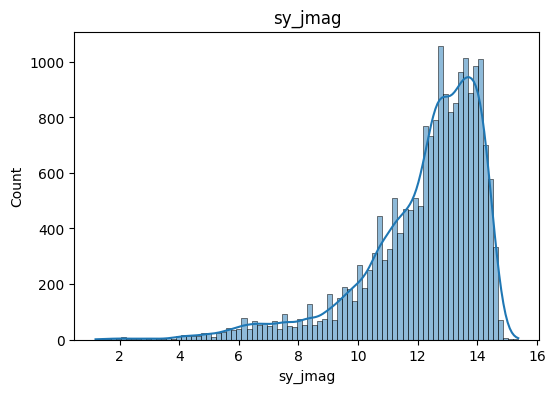

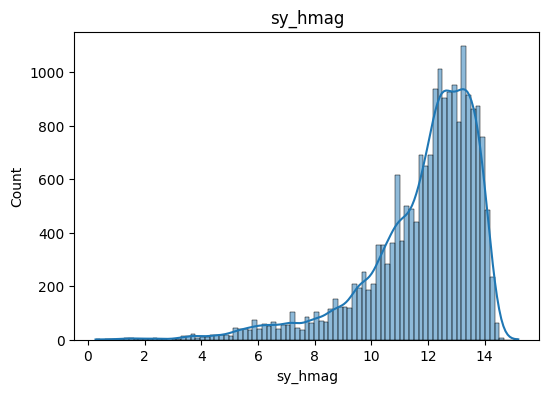

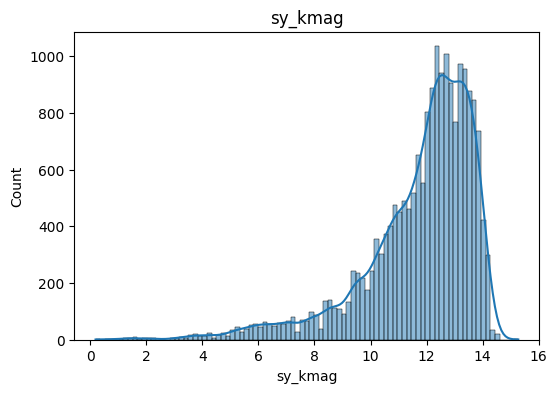

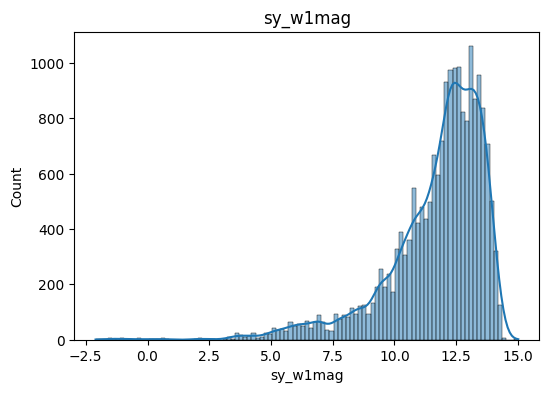

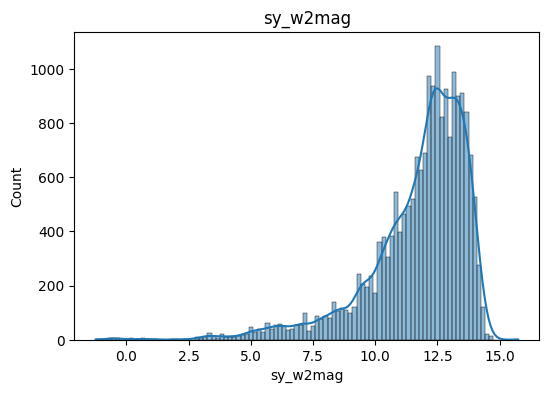

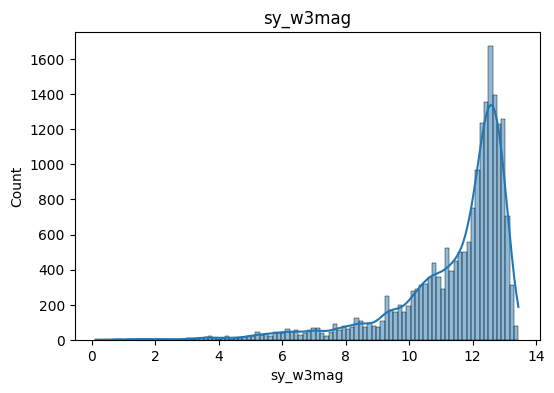

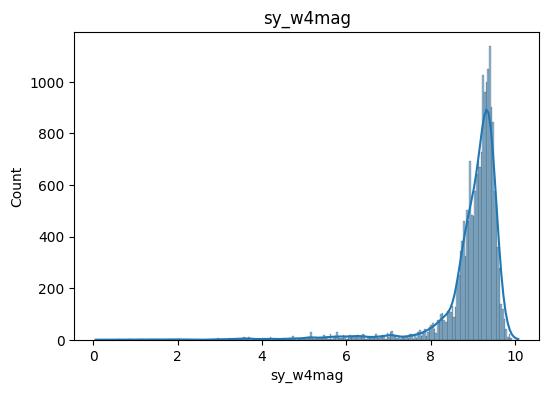

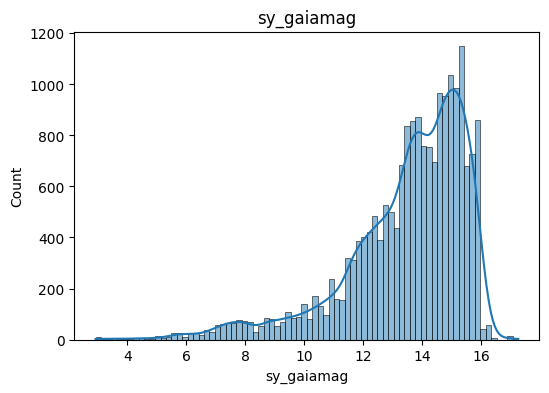

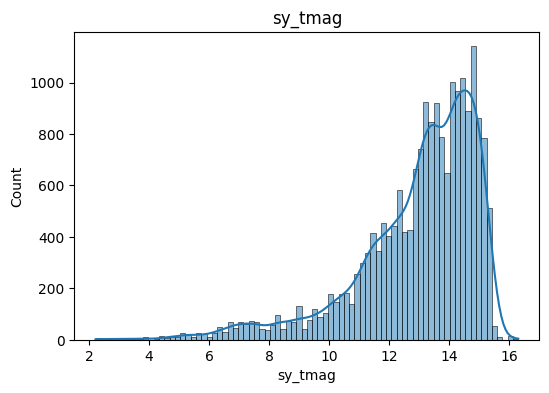

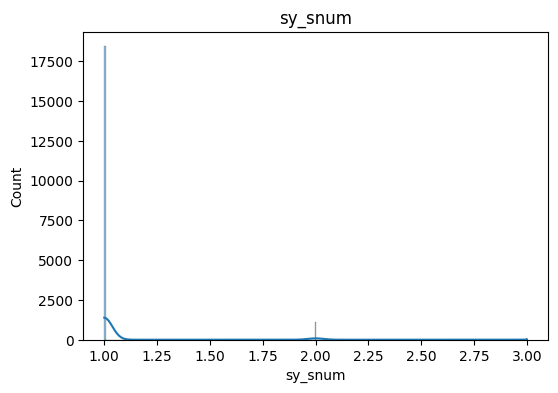

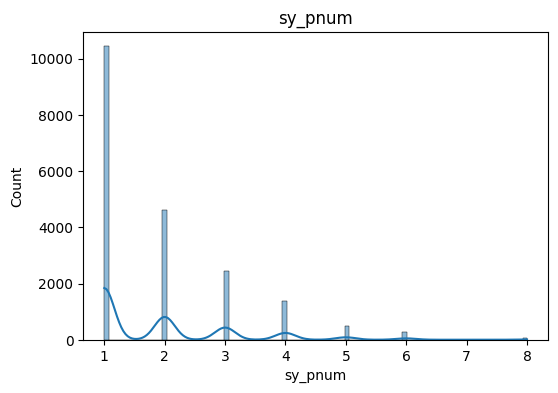

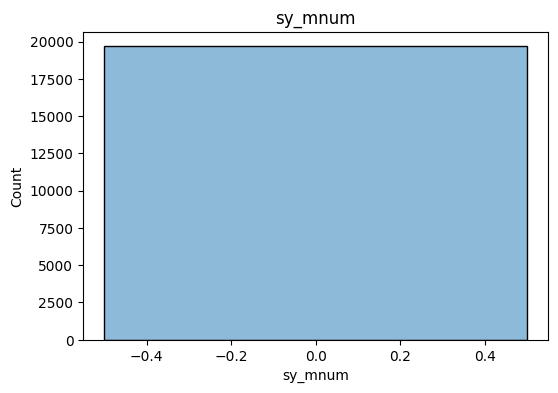

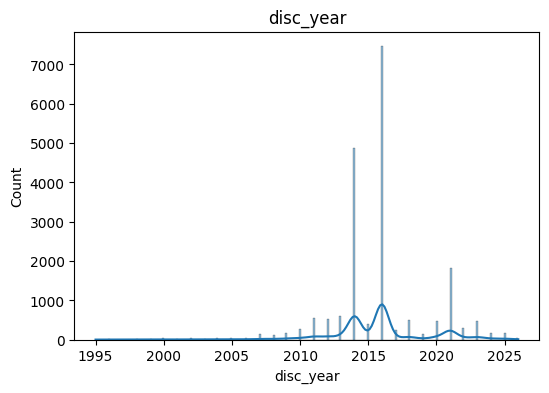

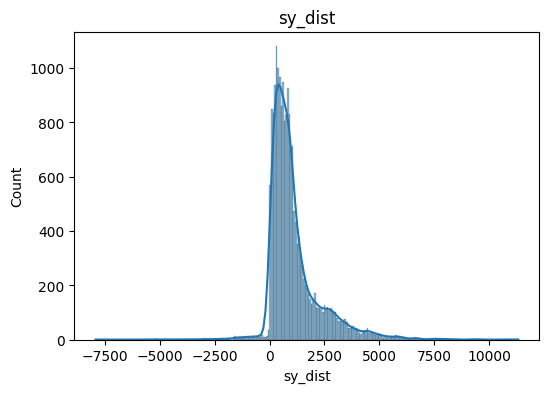

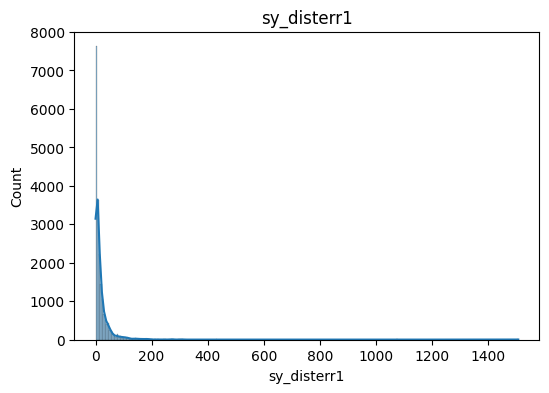

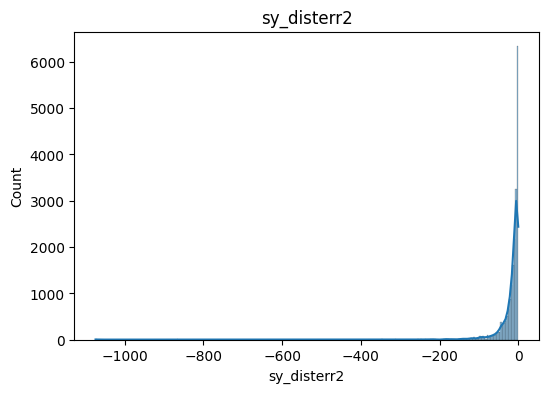

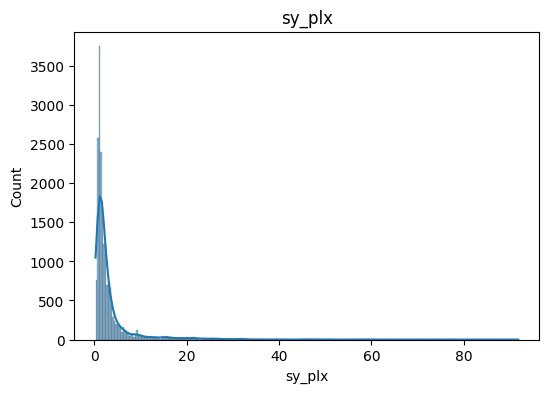

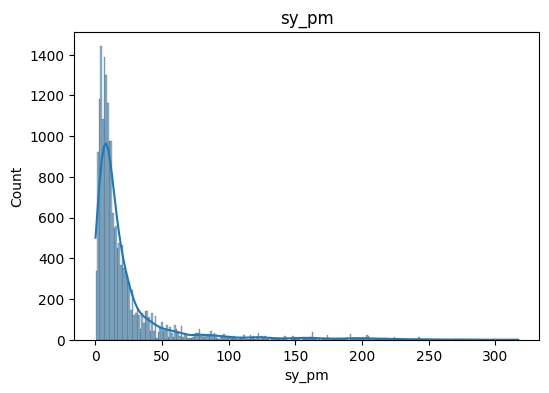

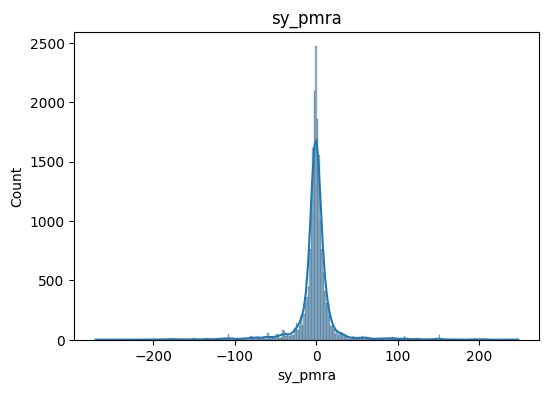

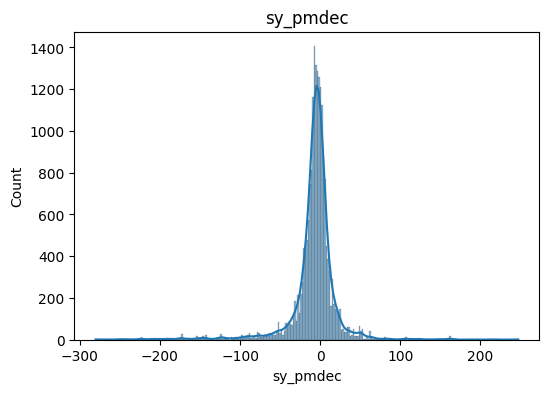

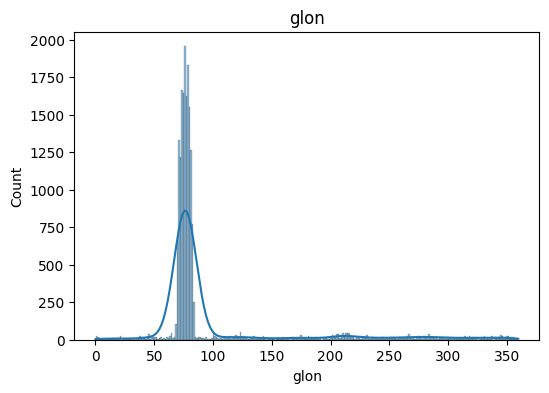

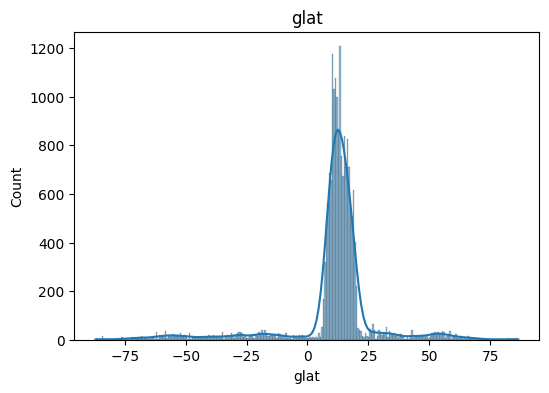

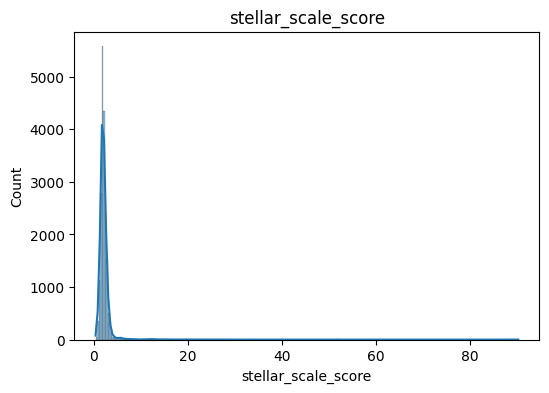

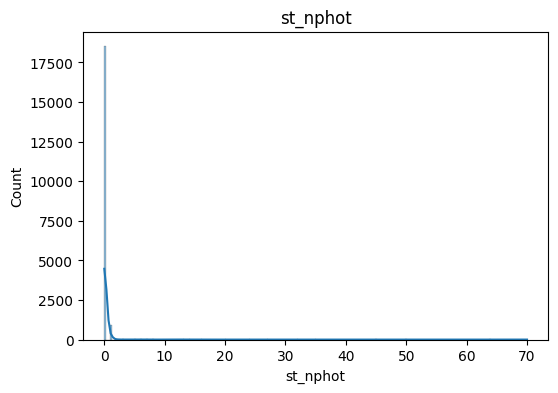

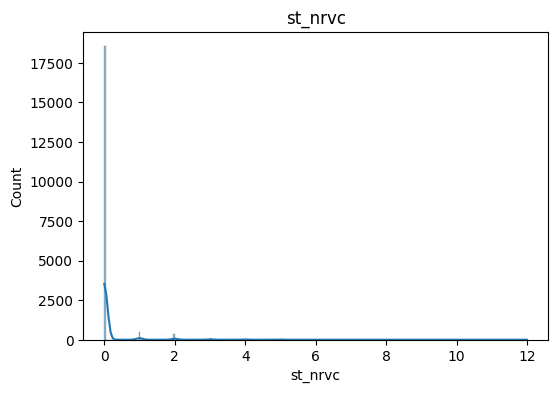

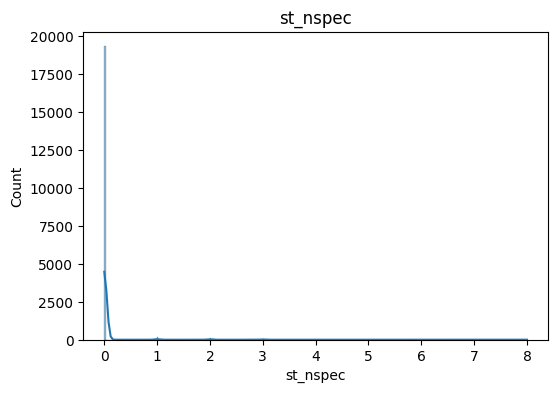

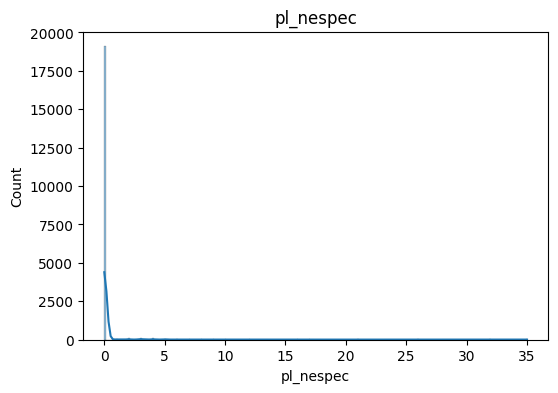

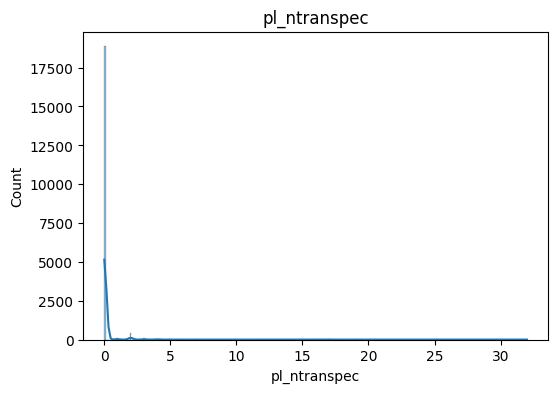

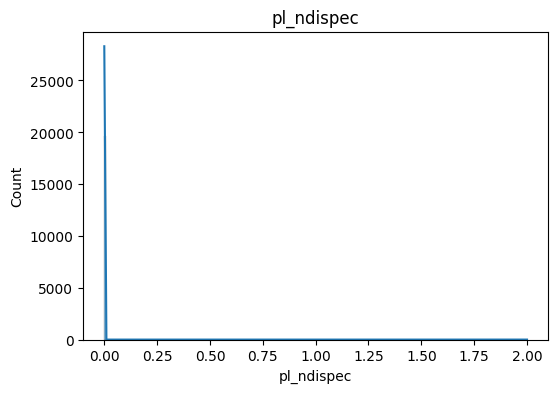

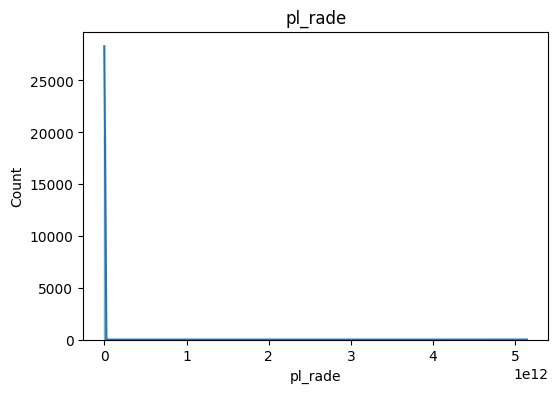

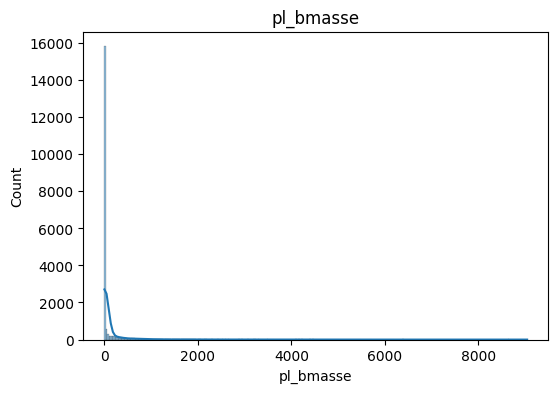

In [18]:
import seaborn as sns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

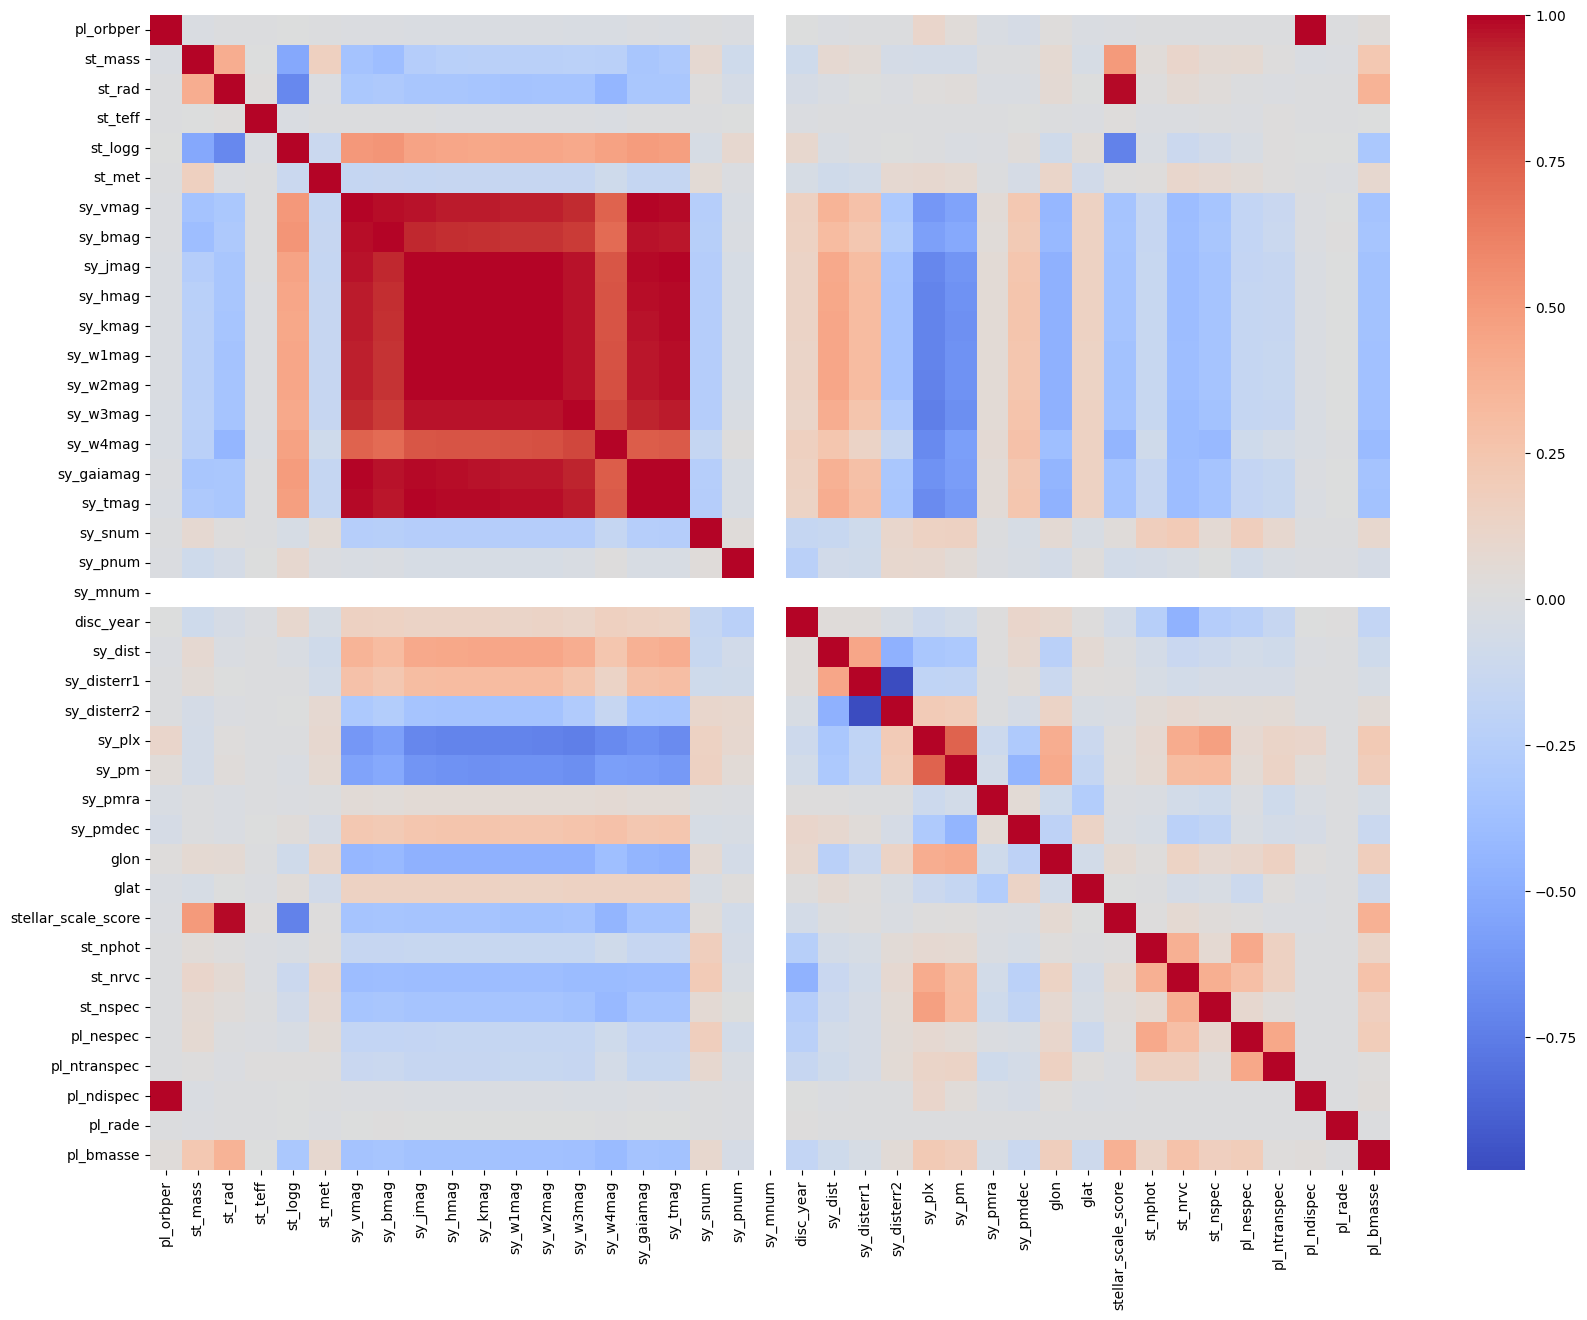

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,15))

sns.heatmap(df.corr(numeric_only=True),
            annot=False,
            cmap='coolwarm')

plt.show()

In [20]:
skew = df.skew(numeric_only=True)

print(skew.sort_values(ascending=False))

pl_ndispec             140.264037
pl_rade                140.264037
pl_orbper              140.264027
st_rad                  21.210517
stellar_scale_score     19.990155
st_mass                 19.137479
sy_disterr1             17.356596
st_nphot                15.219776
pl_ntranspec            14.496239
pl_nespec               13.751208
st_nspec                12.676431
st_nrvc                  8.144990
st_teff                  8.097455
pl_bmasse                7.665949
sy_plx                   5.357552
sy_snum                  4.176010
sy_pm                    3.592069
glon                     2.561732
sy_dist                  1.900323
sy_pnum                  1.586500
st_met                   1.427960
sy_mnum                  0.000000
sy_pmra                 -0.174307
disc_year               -0.242611
sy_bmag                 -1.188847
sy_vmag                 -1.369408
sy_gaiamag              -1.457782
sy_tmag                 -1.526626
sy_jmag                 -1.578951
glat          

In [21]:
kurt = df.kurt(numeric_only=True)

print(kurt.sort_values(ascending=False))

pl_ndispec             19674.000000
pl_rade                19674.000000
pl_orbper              19673.998143
st_mass                 1126.378039
st_rad                   603.052389
stellar_scale_score      558.406086
sy_disterr1              492.332934
sy_disterr2              351.749629
pl_ntranspec             271.066574
st_nphot                 265.132587
pl_nespec                235.697042
st_nspec                 209.573034
st_nrvc                   89.561016
st_met                    78.570293
pl_bmasse                 74.447800
st_teff                   63.577485
sy_plx                    41.191202
st_logg                   23.680944
sy_w4mag                  20.704088
sy_pmra                   19.468316
sy_pmdec                  18.674580
sy_snum                   18.239418
sy_pm                     14.743785
sy_dist                    7.127502
glat                       7.062961
glon                       5.666121
sy_w1mag                   4.643016
sy_w3mag                   4

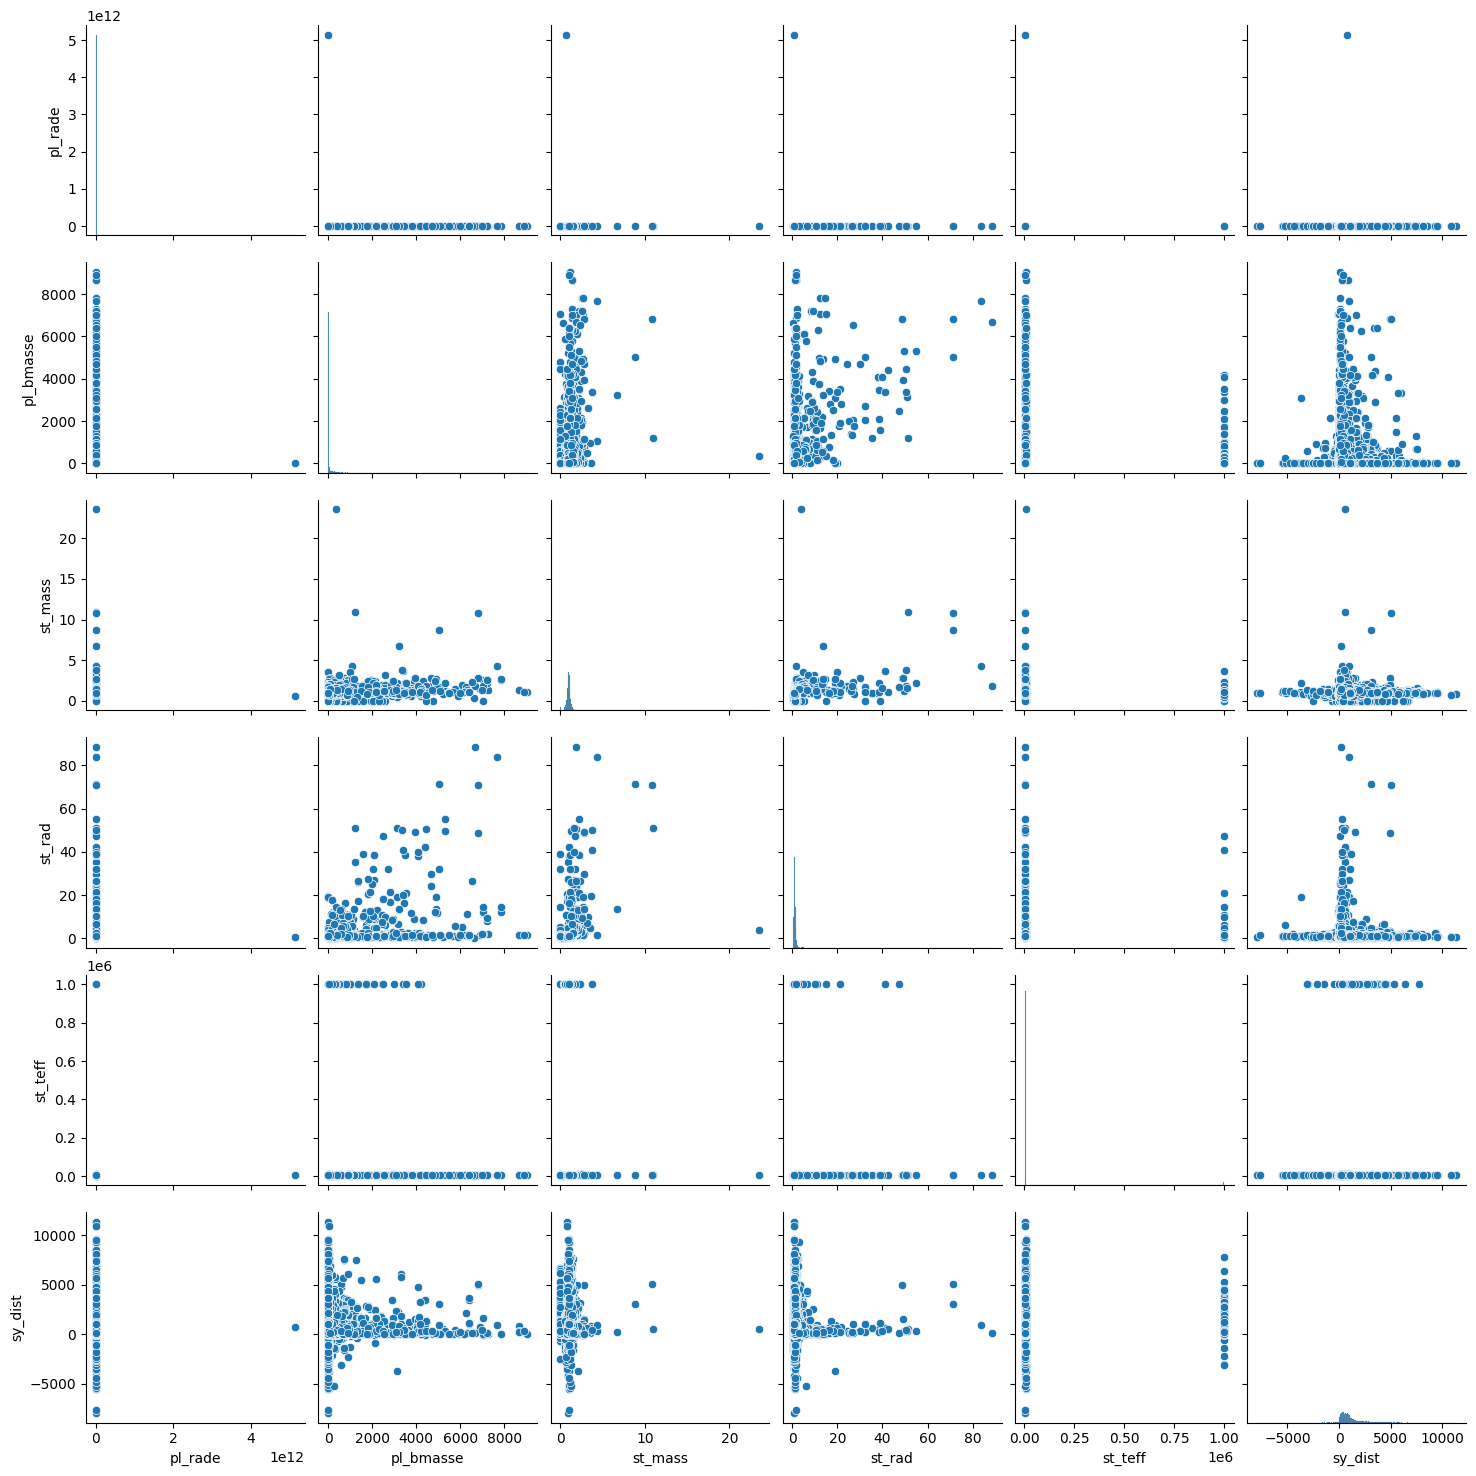

In [22]:
features = [
'pl_rade',
'pl_bmasse',
'st_mass',
'st_rad',
'st_teff',
'sy_dist'
]

sns.pairplot(df[features])

plt.show()

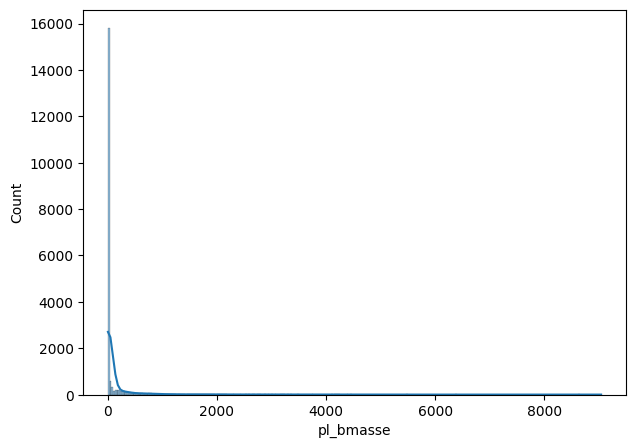

In [23]:
plt.figure(figsize=(7,5))

sns.histplot(df['pl_bmasse'], kde=True)

plt.show()

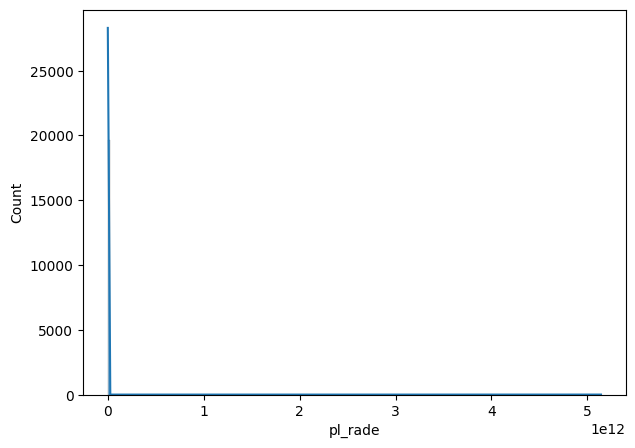

In [24]:
plt.figure(figsize=(7,5))

sns.histplot(df['pl_rade'], kde=True)

plt.show()

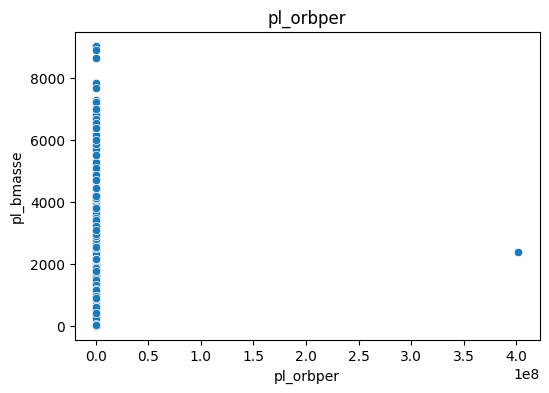

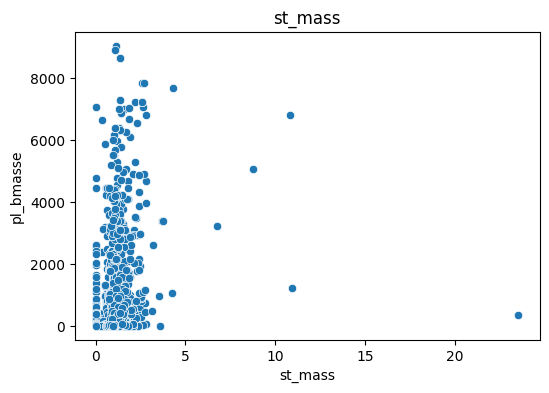

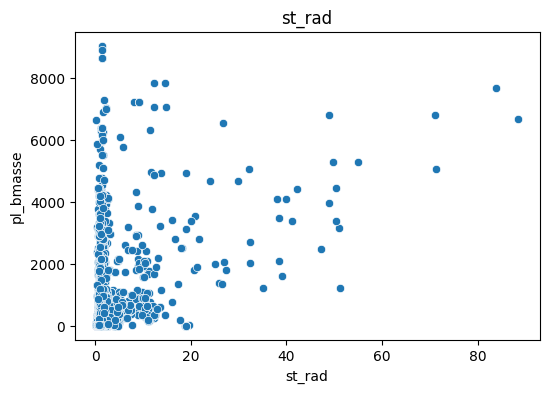

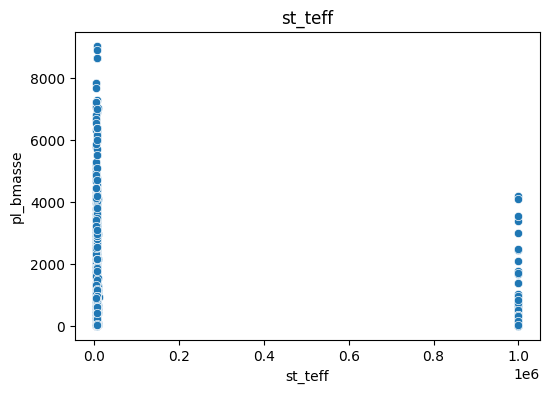

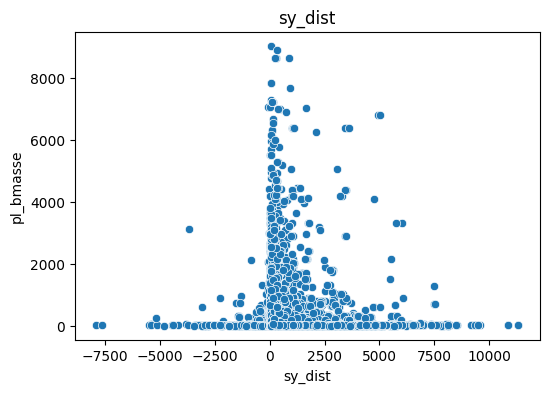

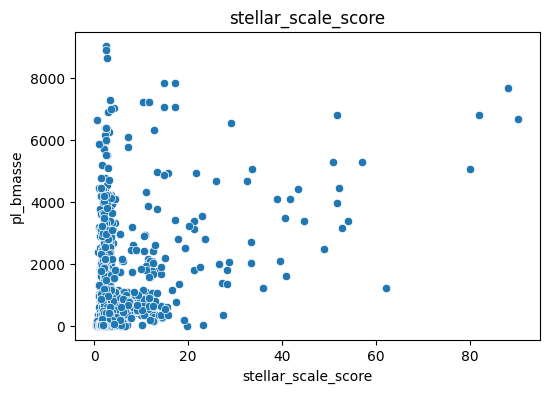

In [25]:
features = [
'pl_orbper',
'st_mass',
'st_rad',
'st_teff',
'sy_dist',
'stellar_scale_score'
]

for col in features:

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        x=df[col],
        y=df['pl_bmasse']
    )

    plt.title(col)

    plt.show()

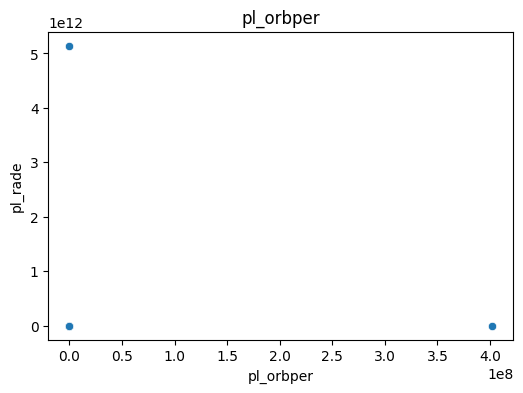

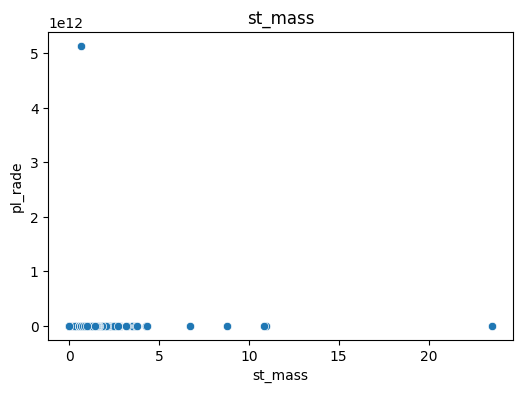

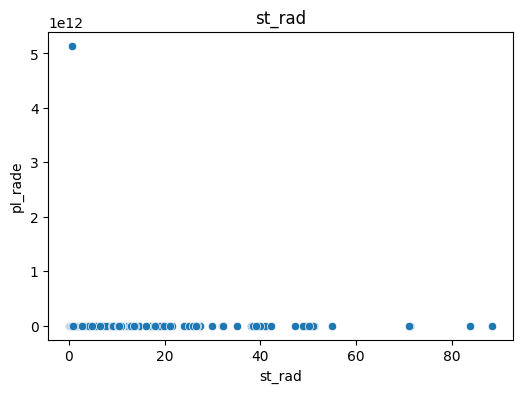

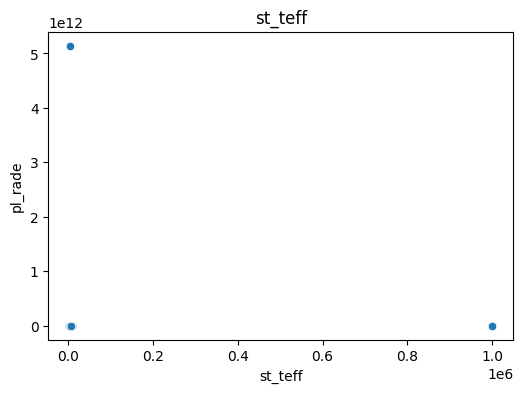

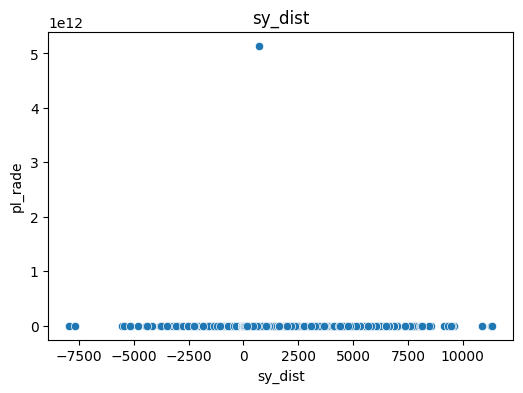

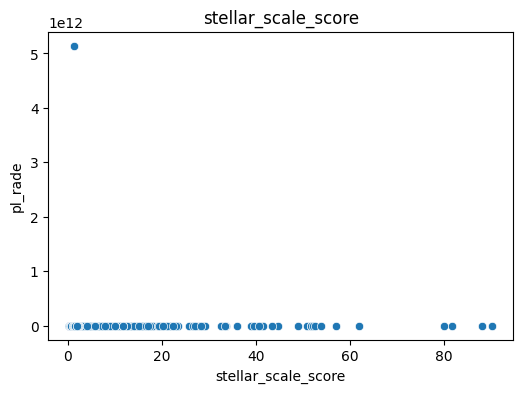

In [26]:
features = [
'pl_orbper',
'st_mass',
'st_rad',
'st_teff',
'sy_dist',
'stellar_scale_score'
]

for col in features:

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        x=df[col],
        y=df['pl_rade']
    )

    plt.title(col)

    plt.show()

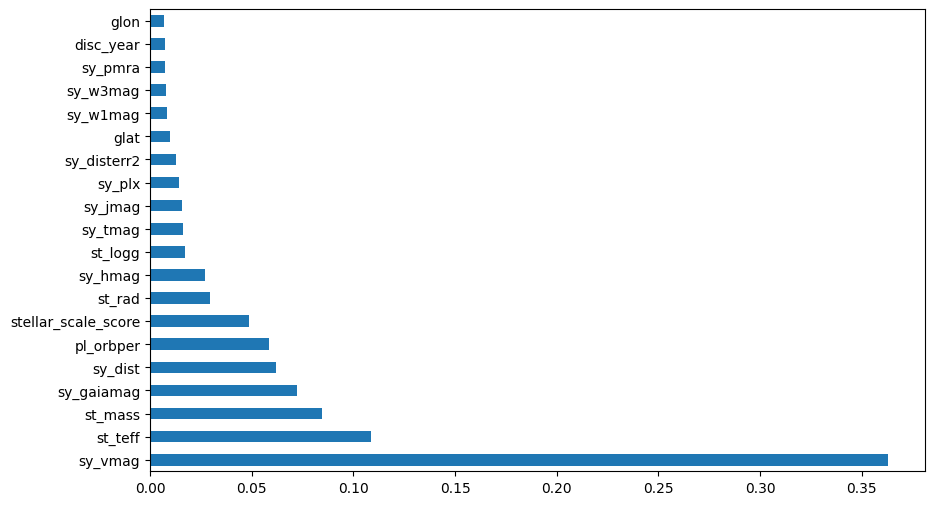

In [27]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop(columns=['pl_bmasse', 'pl_rade'])

y = df[['pl_bmasse', 'pl_rade']]

model = RandomForestRegressor(random_state=42)

model.fit(X,y)

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(20).plot(kind='barh', figsize=(10,6))
plt.show()

In [28]:
import numpy as np

print(np.isinf(X).sum().sum())
print(np.isinf(y).sum())

0
pl_bmasse    0
pl_rade      0
dtype: int64


### Machine Learning Model

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [30]:
print(y.describe())

          pl_bmasse       pl_rade
count  19674.000000  1.967400e+04
mean     139.807264  2.613479e+08
std      566.992018  3.665767e+10
min        0.065000  2.700000e-01
25%        3.330000  1.760000e+00
50%        6.660000  2.302000e+00
75%       15.000000  2.910000e+00
max     9045.396463  5.141752e+12


In [31]:
df.nlargest(20, 'pl_rade')[['pl_rade', 'pl_bmasse']]


,pl_rade,pl_bmasse
39222,5.141752e+12,10.800000
26199,6.502510e+05,6.860000
3807,3.764122e+04,286.682660
23462,3.307068e+04,157.180000
18182,2.938639e+04,17.600000
10572,2.931156e+04,151.916000
5284,2.899228e+04,140.163030
11922,2.838835e+04,266.977200
1993,2.523042e+04,266.977200
24641,2.523042e+04,1102.820000


In [32]:
df[df['pl_rade'] > 100]

,pl_orbper,st_mass,st_rad,st_teff,st_logg,st_met,sy_vmag,sy_bmag,sy_jmag,sy_hmag,...,glat,stellar_scale_score,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec,pl_rade,pl_bmasse
12,168.811174,0.736288,0.723688,4888.452173,4.54200,-0.0400,14.258881,15.491,12.480,11.985,...,11.56055,1.49600,0.0,0.0,0.0,0.0,0.0,0.0,7508.290464,3.820000
78,3452.000000,1.708617,1.784684,5631.669138,3.82000,-0.2000,7.291218,7.905,5.938,5.588,...,-10.02581,3.47800,1.0,2.0,0.0,0.0,0.0,0.0,7518.508389,819.970000
136,3.799847,0.654603,0.710178,4412.669911,4.66700,-0.1270,13.601235,14.832,11.145,10.487,...,8.89777,1.26200,0.0,0.0,0.0,0.0,0.0,0.0,11353.772045,241.550800
140,11.128274,0.506918,0.527406,3624.655464,4.74400,0.2100,17.426843,19.297,14.832,14.224,...,12.00174,1.01600,0.0,0.0,0.0,0.0,0.0,0.0,7632.536280,21.500000
149,3.290305,0.166225,0.228033,3188.210604,5.10400,0.0000,16.733620,18.170,13.141,12.504,...,9.05558,0.35400,0.0,0.0,0.0,0.0,0.0,0.0,7517.623433,35.300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39732,15.923460,0.910301,1.098423,5665.336155,4.33500,-0.1210,9.038366,9.730,7.871,7.546,...,41.33459,1.98560,0.0,0.0,0.0,0.0,0.0,0.0,7525.830385,6.100000
39733,2.988761,1.068208,1.069600,5767.814722,4.38500,0.1910,12.308309,13.366,11.303,10.960,...,2.20726,2.15800,0.0,0.0,0.0,0.0,0.0,0.0,16875.586574,260.619294
39818,9.489655,0.971815,1.740855,5512.633298,3.93911,0.0589,13.775192,14.614,12.576,12.256,...,11.88448,2.70026,0.0,0.0,0.0,0.0,0.0,0.0,7518.508389,4.080000
39826,39.818832,1.004708,1.491499,5707.603568,4.07300,0.0000,13.283195,14.715,12.012,11.694,...,18.12873,2.52700,0.0,0.0,0.0,0.0,0.0,0.0,7516.560255,4.120000


In [36]:
import numpy as np

df['pl_rade_log'] = np.log1p(df['pl_rade'])
df['pl_bmasse_log'] = np.log1p(df['pl_bmasse'])


In [39]:
print(df.shape)
df.columns

(19674, 41)


Index(['pl_orbper', 'st_mass', 'st_rad', 'st_teff', 'st_logg', 'st_met',
       'sy_vmag', 'sy_bmag', 'sy_jmag', 'sy_hmag', 'sy_kmag', 'sy_w1mag',
       'sy_w2mag', 'sy_w3mag', 'sy_w4mag', 'sy_gaiamag', 'sy_tmag', 'sy_snum',
       'sy_pnum', 'sy_mnum', 'disc_year', 'sy_dist', 'sy_disterr1',
       'sy_disterr2', 'sy_plx', 'sy_pm', 'sy_pmra', 'sy_pmdec', 'glon', 'glat',
       'stellar_scale_score', 'st_nphot', 'st_nrvc', 'st_nspec', 'pl_nespec',
       'pl_ntranspec', 'pl_ndispec', 'pl_rade', 'pl_bmasse', 'pl_rade_log',
       'pl_bmasse_log'],
      dtype='str')

In [52]:
X = df.drop(columns=[
    'pl_rade',
    'pl_bmasse',
    'pl_rade_log',
    'pl_bmasse_log'
])

y = df[['pl_bmasse_log']]

In [53]:
print(y)

       pl_bmasse_log
0           0.448086
4           0.959135
7           0.854699
9           1.046777
10          1.862977
...              ...
39899       1.310506
39901       2.052855
39905       1.201273
39908       1.647119
39909       0.868692

[19674 rows x 1 columns]


In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [55]:

from xgboost import XGBRegressor
model = MultiOutputRegressor(
    XGBRegressor(
        objective='reg:squarederror',
        n_estimators=1000,
        learning_rate=0.01,
        max_depth=8,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1,
        random_state=42,
        n_jobs=-1
    )
)

model.fit(X_train, y_train)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,"XGBRegressor(...ree=None, ...)"
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary <n_jobs>` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
Name,Type,Value
estimators_ estimators_: list of ``n_output`` estimatorsEstimators used for predictions.,list,"[XGBRegressor(...ree=None, ...)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[<U19](37,)","['pl_orbper','st_mass','st_rad',...,'pl_nespec','pl_ntranspec', 'pl_ndispec']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying `estimator` exposes such an attribute when fit... versionadded:: 0.24,int,37
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None


In [56]:
y_pred = model.predict(X_test)

In [57]:
y_pred

array([[1.035812  ],
       [0.82122403],
       [1.1383471 ],
       ...,
       [0.8423341 ],
       [1.666927  ],
       [0.9768407 ]], shape=(3935, 1), dtype=float32)

In [58]:
print("R² Score :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score : 0.8793092370033264
MAE : 0.10561851412057877
RMSE : 0.14397330458375246


In [ ]:
X = df.drop(columns=[
    'pl_rade',
    'pl_bmasse',
    'pl_rade_log',
    'pl_bmasse_log'
])

y1 = df[['pl_rade_log']]

In [ ]:
X_train, X_test, y1_train, y1_test = train_test_split(
    X,
    y1,
    test_size=0.2,
    random_state=42)

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
model = ExtraTreesRegressor(
    n_estimators=1000,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

In [ ]:
model.fit(X1_train, y1_train)


In [ ]:
y_pred = model.predict(X_test)


In [ ]:
y_pred = np.expm1(y_pred_log)

In [ ]:
### Model Evalus

In [ ]:
print("R² Score :", r2_score(y1_test, y_pred))
print("MAE :", mean_absolute_error(y1_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y1_test, y_pred)))